## Importing Libraries and Loading the Data

In this section we import the required libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\e-commerce-orange-report\Datasets\data.csv", encoding="latin1")
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")



✅ Loaded: 541,909 rows × 8 columns


# Dataset Overview

We start by understanding the general structure of the dataset.
This includes checking the number of rows and columns and viewing a few sample records.

In [3]:
df.shape

(541909, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Column Understanding

Each column represents specific information about transactions in the dataset.

- **InvoiceNo** → (Object): A unique 6-digit identifier for each transaction. Expected to be non-null. Entries starting with "C" indicate cancelled orders.
- **StockCode** → (Object): A unique product/item code. Expected to be non-null and unique per product type.
- **Description** → (Object): The name/label of the product. Categorical. Should not be empty; missing values indicate unknown items.
- **Quantity** → (Integer): Number of units purchased per transaction. Numeric. Should be non-zero; negative values indicate returns/refunds.
- **InvoiceDate** → (Object → DateTime): The date and time the transaction was recorded. Should be converted to datetime format. Must not be a future date.
- **UnitPrice** → (Float): The price per unit in GBP. Numeric. Must be non-negative; zero or negative values are invalid.
- **CustomerID** → (Float → Object): A unique 5-digit identifier for the customer. Nullable — missing means the customer was a guest/unregistered.
- **Country** → (Object): The country where the customer is located. Categorical. Should have a limited set of valid country names.

## Data Types Check

We verify that each column has the correct data type.
Below we display the current types and identify any columns that need conversion.

In [7]:
# Display current data types
print("Current Data Types:")
print(df.dtypes)

Current Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


### Type Problems Identified & Proposed Fixes

| Column | Current Type | Problem | Proposed Fix |
|---|---|---|---|
| InvoiceDate | object | Date stored as string | `pd.to_datetime(df['InvoiceDate'])` |
| CustomerID | float64 | ID stored as float (should be string/object) | `.fillna("Guest").astype(object)` |
| InvoiceNo | object | Contains mixed values (digits + "C" prefix for cancellations) | Keep as object, flag "C" prefix separately |

In [8]:
# convert invoice date if needed
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Cleaning & Preprocessing

Before performing analysis we check data quality issues such as:
- missing values
- duplicate rows
- invalid values
- inconsistent text formatting

## Missing Values

We check how many missing values exist in each column.

In [9]:
missing_count = df.isna().sum()
missing_percent = df.isna().mean() * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

# Format the "Missing %" column to show as percentages
missing_report["Missing %"] = missing_report["Missing %"].apply(lambda x: f"{x:.2f}%")

missing_report

,Missing Count,Missing %
InvoiceNo,0,0.00%
StockCode,0,0.00%
Description,1454,0.27%
Quantity,0,0.00%
InvoiceDate,0,0.00%
UnitPrice,0,0.00%
CustomerID,135080,24.93%
Country,0,0.00%


### Missing Handling Plan

- **Description** → Drop rows (missing descriptions cannot be inferred)
- **CustomerID** → I will give it a value of Guset And note that the customer is unknown Guset

In [10]:
df['CustomerID'] = df['CustomerID'].fillna("Guest").astype(object)
print(df.isnull().sum())

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64


#### Duplicate Rows

Duplicate rows may occur due to data entry or merging errors.

In [11]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(5268)

In [12]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


Since duplicate rows do not add new information, we remove them to avoid bias in the analysis.

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()

In [14]:
# Verify duplicates were removed
df.duplicated().sum()

np.int64(0)

## Key Duplicates Check (InvoiceNo)

We check whether `InvoiceNo` — the transaction identifier — contains duplicate values.
Note: InvoiceNo is NOT expected to be fully unique because one invoice can contain multiple products (multiple rows per invoice). However, we check for exact (InvoiceNo + StockCode) duplicate combinations, which should be unique.

In [15]:
# Check total unique InvoiceNo values
print(f"Total rows: {df.shape[0]}")
print(f"Unique InvoiceNo values: {df['InvoiceNo'].nunique()}")
print(f"Duplicate InvoiceNo count (same invoice appears more than once): {df['InvoiceNo'].duplicated().sum()}")

# Check for duplicate (InvoiceNo + StockCode) combinations — these should be unique
dup_key = df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)
print(f"\nDuplicate (InvoiceNo + StockCode) combinations: {dup_key.sum()}")

# Show examples
print("\nSample duplicate (InvoiceNo + StockCode) rows:")
df[dup_key].sort_values('InvoiceNo').head(10)

Total rows: 536641
Unique InvoiceNo values: 25900
Duplicate InvoiceNo count (same invoice appears more than once): 510741

Duplicate (InvoiceNo + StockCode) combinations: 10615

Sample duplicate (InvoiceNo + StockCode) rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
491,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
498,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,1,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
502,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
525,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,2,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
575,536412,22144,CHRISTMAS CRAFT LITTLE FRIENDS,2,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
576,536412,22243,5 HOOK HANGER RED MAGIC TOADSTOOL,3,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
577,536412,22077,6 RIBBONS RUSTIC CHARM,7,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


### Decision

- `InvoiceNo` alone is **not unique by design** — one invoice covers multiple product lines.
- However, the combination of `(InvoiceNo + StockCode)` **should be unique**. Any duplicates here represent genuine data entry errors and will be flagged.
- If duplicates exist in this combination, they should be dropped using `df.drop_duplicates(subset=['InvoiceNo', 'StockCode'])`.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Category Cleanliness

We check for inconsistent labels in categorical columns such as extra spaces, mixed casing, or typos.

In [16]:
# --- Check Country column ---
print("=== Country Column ===")
print(f"Unique values: {df['Country'].nunique()}")
print(df['Country'].value_counts())

# Check for leading/trailing spaces
space_issues_country = df['Country'].str.strip() != df['Country']
print(f"\nCountry values with leading/trailing spaces: {space_issues_country.sum()}")

# Check for casing inconsistencies
print("\nCountry values with mixed casing (sample):")
print(df['Country'].unique()[:20])

=== Country Column ===
Unique values: 38
Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community   

In [17]:
print("=== Description Column ===")

# Check for leading/trailing spaces
space_issues_desc = df['Description'].str.strip() != df['Description']
print(f"Description values with leading/trailing spaces: {space_issues_desc.sum()}")

# Check for ALL CAPS entries
all_caps = df['Description'].fillna('').str.isupper()
print(f"ALL CAPS descriptions: {all_caps.sum()}")
print(df.loc[all_caps, 'Description'].value_counts().head(10))

# Check for lowercase entries
all_lower = df['Description'].fillna('').str.islower()
print(f"\nAll lowercase descriptions: {all_lower.sum()}")

=== Description Column ===
Description values with leading/trailing spaces: 113825
ALL CAPS descriptions: 532105
Description
WHITE HANGING HEART T-LIGHT HOLDER    2357
REGENCY CAKESTAND 3 TIER              2189
JUMBO BAG RED RETROSPOT               2156
PARTY BUNTING                         1720
LUNCH BAG RED RETROSPOT               1625
ASSORTED COLOUR BIRD ORNAMENT         1488
SET OF 3 CAKE TINS PANTRY DESIGN      1465
PACK OF 72 RETROSPOT CAKE CASES       1367
LUNCH BAG  BLACK SKULL.               1323
NATURAL SLATE HEART CHALKBOARD        1272
Name: count, dtype: int64

All lowercase descriptions: 493


In [18]:
# --- Apply Cleaning ---

# 1. Strip whitespace from Country and Description
df['Country'] = df['Country'].str.strip()
df['Description'] = df['Description'].str.strip()

# 2. Standardize Description to Title Case
df['Description'] = df['Description'].str.title()

# 3. Standardize Country to Title Case
df['Country'] = df['Country'].str.title()

print("Category cleaning complete.")
print(f"Sample cleaned Country values: {df['Country'].unique()[:10]}")
print(f"Sample cleaned Description values: {df['Description'].unique()[:10]}")

Category cleaning complete.
Sample cleaned Country values: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'Eire' 'Switzerland' 'Spain' 'Poland']
Sample cleaned Description values: ['White Hanging Heart T-Light Holder' 'White Metal Lantern'
 'Cream Cupid Hearts Coat Hanger' 'Knitted Union Flag Hot Water Bottle'
 'Red Woolly Hottie White Heart.' 'Set 7 Babushka Nesting Boxes'
 'Glass Star Frosted T-Light Holder' 'Hand Warmer Union Jack'
 'Hand Warmer Red Polka Dot' 'Assorted Colour Bird Ornament']


### Cleaning Plan Summary

| Column | Problem Found | Action Taken |
|---|---|---|
| Country | Possible leading/trailing spaces, mixed casing | `.str.strip()` + `.str.title()` |
| Description | Mixed casing, ALL CAPS entries, extra spaces | `.str.strip()` + `.str.title()` |

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Validity Checks

We check whether the dataset contains unrealistic values such as:

- negative prices
- extremely large quantities

In [19]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust Bad Debt,1,2011-08-12 14:51:00,-11062.06,Guest,United Kingdom
299984,A563187,B,Adjust Bad Debt,1,2011-08-12 14:52:00,-11062.06,Guest,United Kingdom


In [20]:
df.drop(df[df["UnitPrice"] < 0].index, inplace=True)

In [21]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,Set Of 3 Coloured Flying Ducks,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,Plasters In Tin Circus Parade,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,Pack Of 12 Pink Paisley Tissues,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,Pack Of 12 Blue Paisley Tissues,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,Zinc T-Light Holder Stars Small,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,Victorian Sewing Box Large,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,Hanging Heart Jar T-Light Holder,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


Negative revenue values represent refunds and returns, reflecting deductions from total sales.

In [22]:
df[df["Quantity"] > 10000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,Medium Ceramic Top Storage Jar,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,Asstd Design 3D Paper Stickers,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
540421,581483,23843,"Paper Craft , Little Birdie",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


After reading the description, it seems these are genuine products and not Outlayer, so they will remain as they are.

In [23]:
df['Description'] = df['Description'].fillna('Unknown Item')
print("Data shape after full cleaning:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Data shape after full cleaning: (536639, 8)
Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Replace all empty descriptions with 'Unknown Item' to have complete data

In [24]:
# The number of values ​​that are equal to zero
zero_count = (df['UnitPrice'] == 0).sum()

# Total number of rows
total_rows = len(df)

# Calculate percentage
zero_percent = (zero_count / total_rows) * 100

print(f"Number of UnitPrice = 0 values: {zero_count}")
print(f"Percentage of UnitPrice = 0 values: {zero_percent:.2f}%")

Number of UnitPrice = 0 values: 2510
Percentage of UnitPrice = 0 values: 0.47%


In [25]:
df = df[df['UnitPrice'] != 0]

## Feature Engineering

In [26]:
# 1. Direct and safe date conversion (format='mixed' handles mixed date formats)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

# 2. Extract time components for analysis and visualization
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayName'] = df['InvoiceDate'].dt.day_name()

# 3. Display the result to verify
display(df[['InvoiceDate', 'Year', 'Month', 'Day', 'Hour', 'DayName']].head())

,InvoiceDate,Year,Month,Day,Hour,DayName
0,2010-12-01 08:26:00,2010,12,1,8,Wednesday
1,2010-12-01 08:26:00,2010,12,1,8,Wednesday
2,2010-12-01 08:26:00,2010,12,1,8,Wednesday
3,2010-12-01 08:26:00,2010,12,1,8,Wednesday
4,2010-12-01 08:26:00,2010,12,1,8,Wednesday


Enable time-based analysis (hourly, daily, monthly, yearly trends)

To Identify peak sales hours and busy days

And Detect seasonal patterns and trends

In [27]:
df['Is_Return'] = df['Quantity'] < 0

In this step, we created a boolean column `Is_Return` to flag transactions where the **Quantity** is less than zero.

In [28]:
df['Country'] = df['Country'].replace('Israel', 'Palestine')

In [29]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Hour,DayName,Is_Return,Sales
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34


## Export Clean Dataset

After completing the data cleaning process, we export a cleaned version of the dataset.

This dataset will be used later for visualization and dashboard creation in Power BI.

In [30]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)

In [31]:
df.shape

(534129, 15)

# Exploration Data Analysis

In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Hour,DayName,Is_Return,Sales
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,15.30
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,22.00
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,False,20.34


## Numeric Summary

We examine the main statistics of numeric variables to understand their central tendency and spread.

In [33]:
df.describe().round(2)

,Quantity,InvoiceDate,UnitPrice,Year,Month,Day,Hour,Sales
count,534129.00,534129,534129.00,534129.00,534129.00,534129.00,534129.00,534129.00
mean,9.92,2011-07-04 12:02:01.631403776,4.70,2010.92,7.55,15.02,13.08,18.25
min,-80995.00,2010-12-01 08:26:00,0.00,2010.00,1.00,1.00,6.00,-168469.60
25%,1.00,2011-03-28 11:36:00,1.25,2011.00,5.00,7.00,11.00,3.75
50%,3.00,2011-07-19 15:55:00,2.10,2011.00,8.00,15.00,13.00,9.90
75%,10.00,2011-10-18 17:10:00,4.13,2011.00,11.00,22.00,15.00,17.57
max,80995.00,2011-12-09 12:50:00,38970.00,2011.00,12.00,31.00,20.00,168469.60
std,216.45,NaN,95.08,0.27,3.51,8.66,2.45,380.95


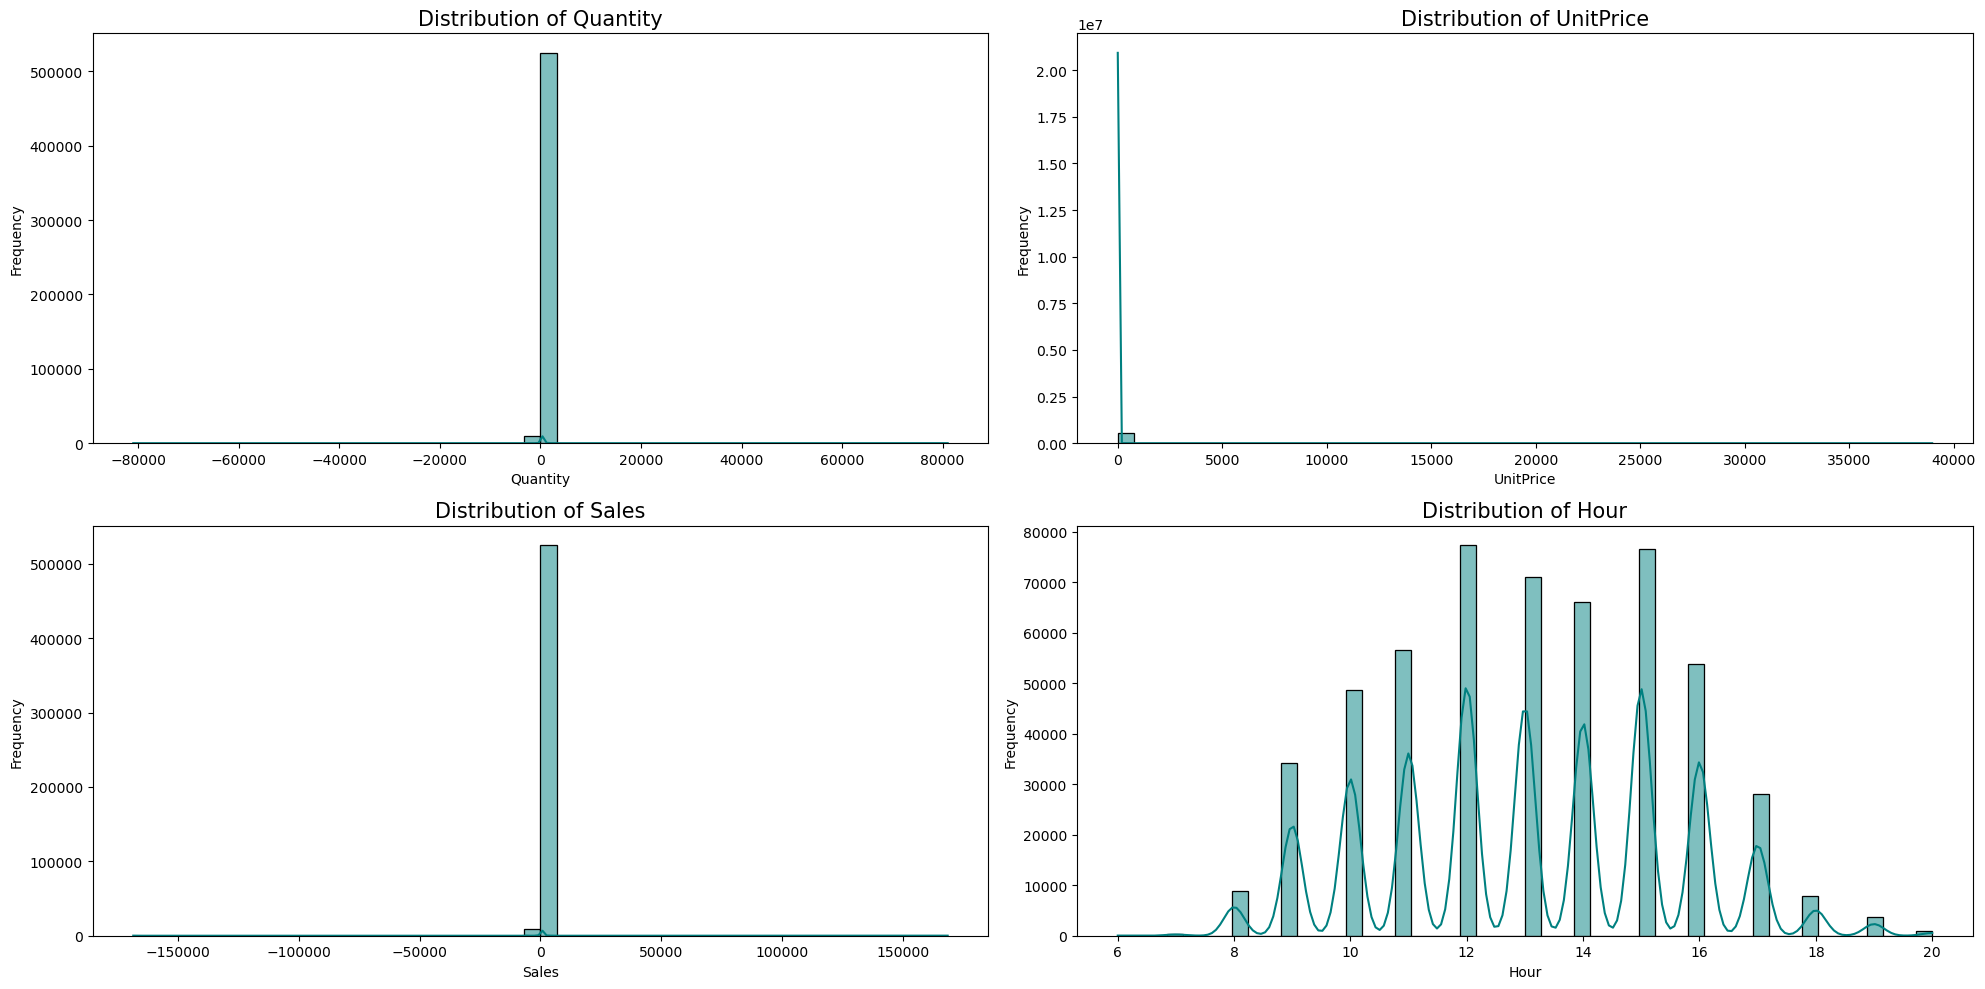

In [34]:
# 1. Select the numeric columns we want to examine
numeric_cols = ['Quantity', 'UnitPrice', 'Sales', 'Hour']

# 2. Preparing Subplots
plt.figure(figsize=(20, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    
    # Plot the distribution with the density curve
    sns.histplot(df[col], kde=True, bins=50, color='teal')
    
    # Add clear titles
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [35]:


df['Log_Quantity'] = np.log1p(df['Quantity'].clip(lower=0))
df['Log_UnitPrice'] = np.log1p(df['UnitPrice'])
df['Log_Sales'] = np.log1p(df['Sales'].clip(lower=0))

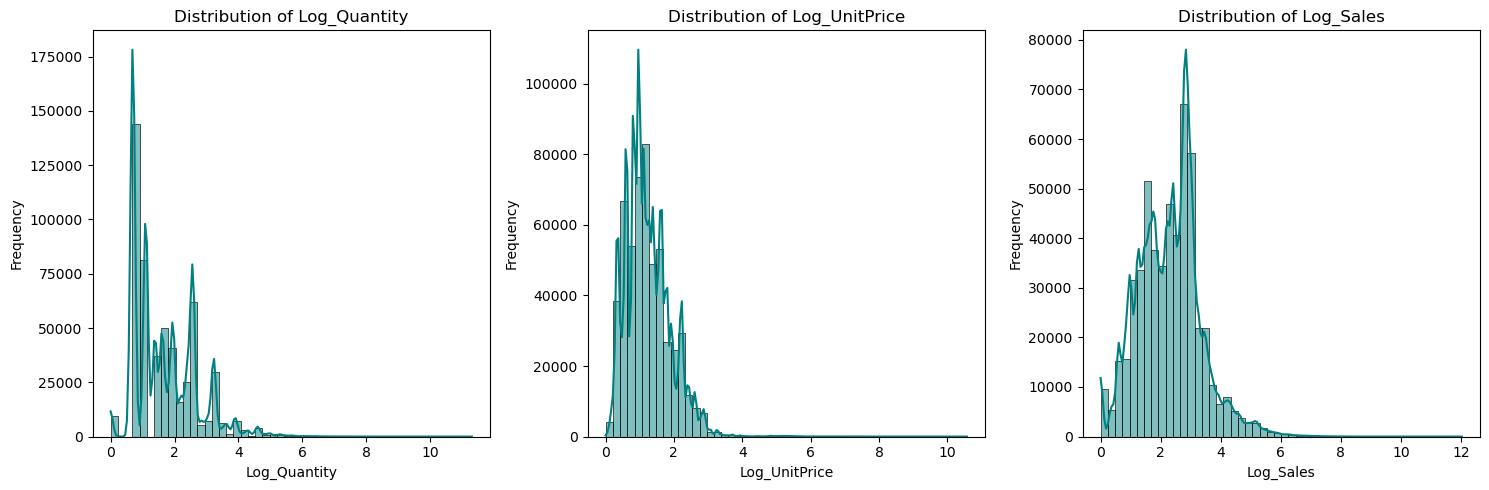

In [36]:
log_cols = ['Log_Quantity', 'Log_UnitPrice', 'Log_Sales']

plt.figure(figsize=(15,5))

for i, col in enumerate(log_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], kde=True, bins=50, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Distribution After Log Transformation

The histograms above show the distributions of **Log_Quantity**, **Log_UnitPrice**, and **Log_Sales** after applying a logarithmic transformation to the original variables.

The purpose of applying the **log transformation** is to reduce the skewness of the data and minimize the impact of extreme values (outliers), which are common in retail transaction datasets.

- **Log_Quantity:**  
  The distribution shows that most purchase quantities are relatively small. After the transformation, the values are more compressed, making the distribution easier to analyze compared to the highly skewed original quantity values.

- **Log_UnitPrice:**  
  The distribution indicates that most product prices are concentrated at lower values, with fewer products having high prices. The log transformation reduces the effect of large price values and creates a smoother distribution.

- **Log_Sales:**  
  Since **Sales = Quantity × UnitPrice**, the distribution reflects overall transaction values. After applying the log transformation, the distribution becomes less skewed and more suitable for further statistical analysis or modeling.

Overall, the log transformation helps stabilize variance and makes the data distribution closer to a normal distribution, which improves the reliability of further analysis and visualization.

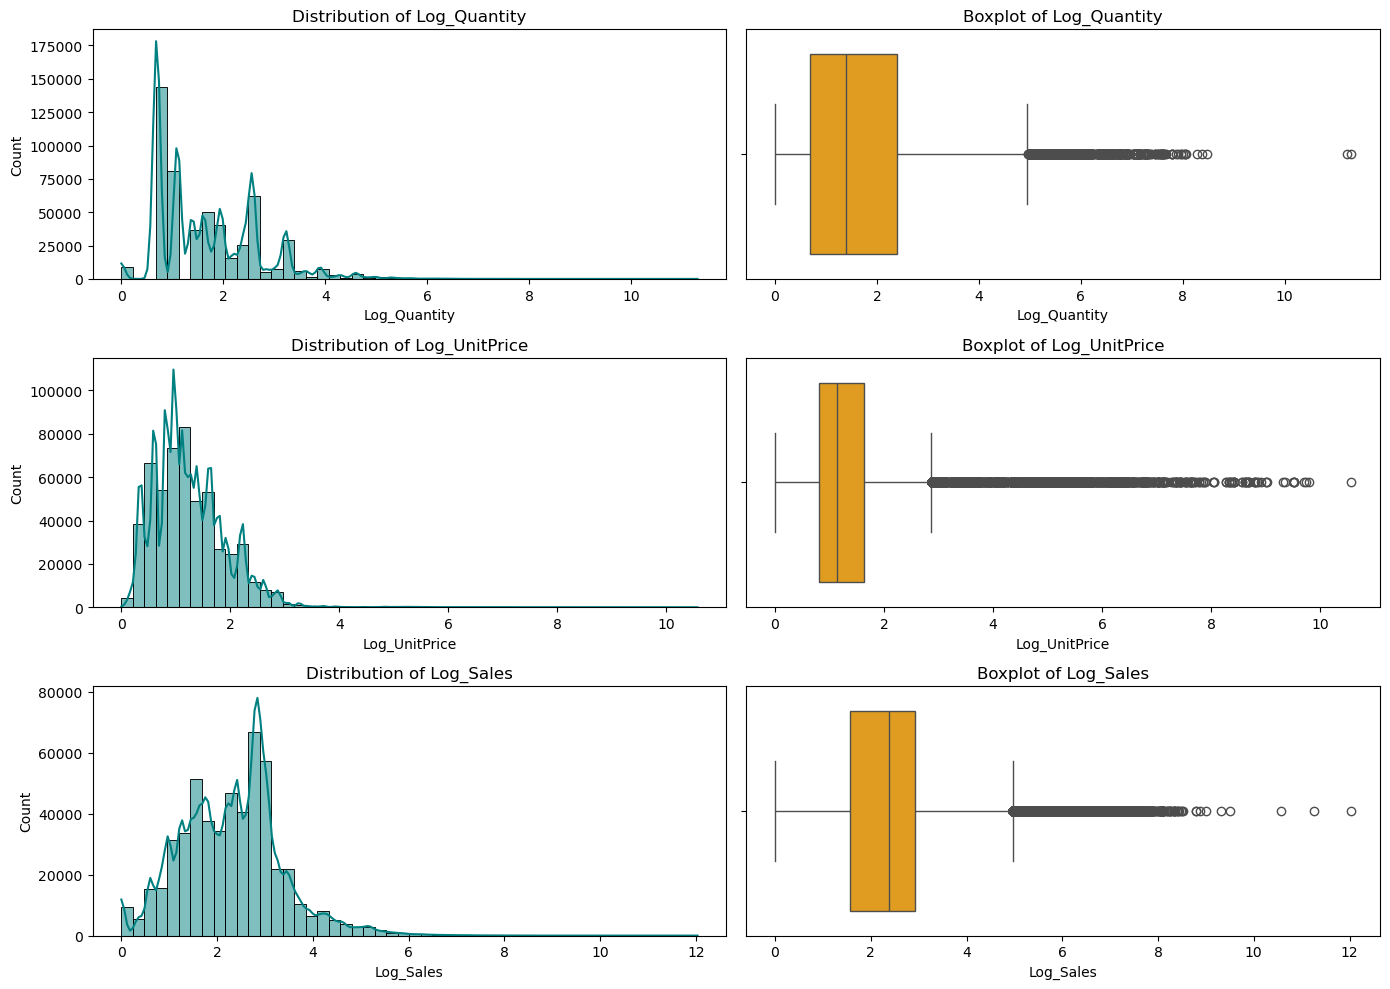

In [37]:
cols = ['Log_Quantity', 'Log_UnitPrice', 'Log_Sales']

plt.figure(figsize=(14,10))

for i, col in enumerate(cols):
    
    # Distribution plot
    plt.subplot(len(cols), 2, i*2 + 1)
    sns.histplot(df[col], kde=True, bins=50, color='teal')
    plt.title(f'Distribution of {col}')
    
    # Boxplot
    plt.subplot(len(cols), 2, i*2 + 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Distribution and Outlier Analysis

The plots above combine both the **distribution (histogram with KDE)** and **boxplot** for each numerical variable: Quantity, UnitPrice, and Sales.

The histogram helps visualize the overall data distribution and skewness, while the boxplot highlights the presence of **outliers** and the spread of the data.

From these visualizations, it is clear that the variables are highly **right-skewed**, which is common in retail transaction datasets where most purchases are small but a few transactions have very large values. The boxplots also reveal the presence of extreme values that may represent bulk purchases, data entry issues, or unusual transactions.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\45913495.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette='viridis')


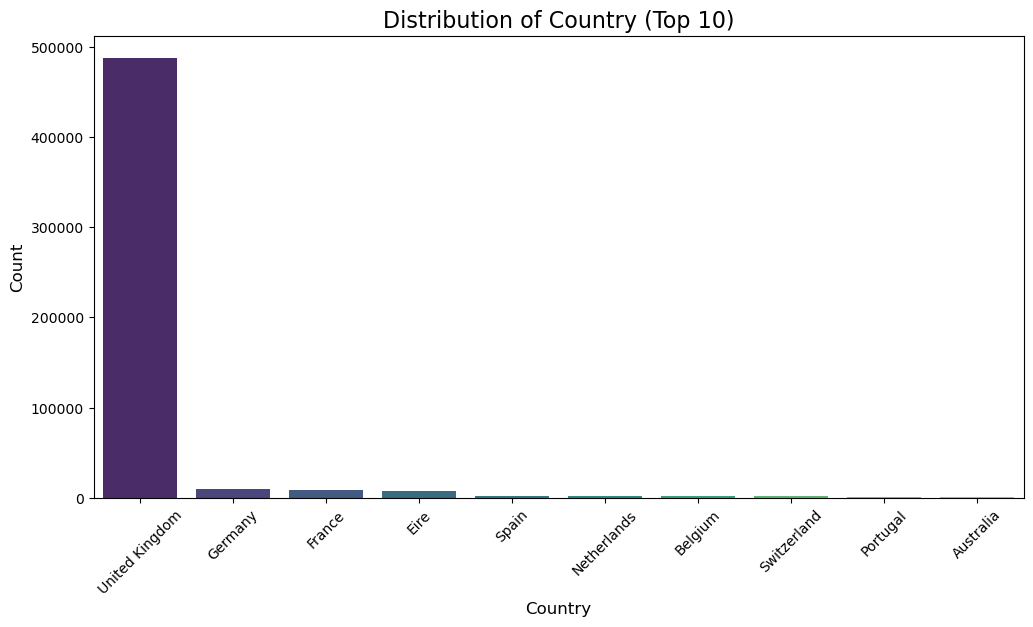

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\45913495.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette='viridis')


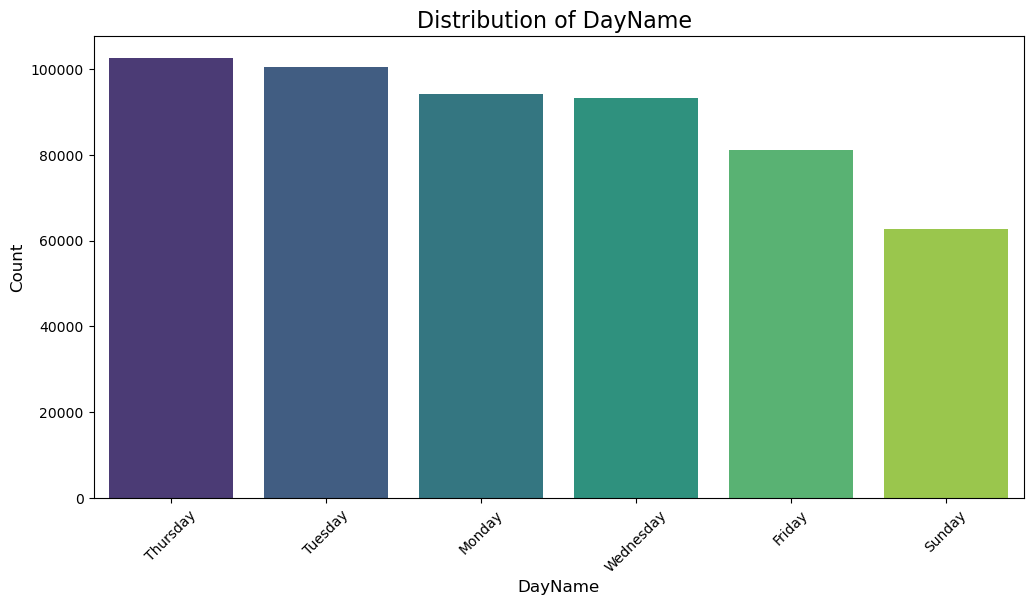

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\45913495.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette='viridis')


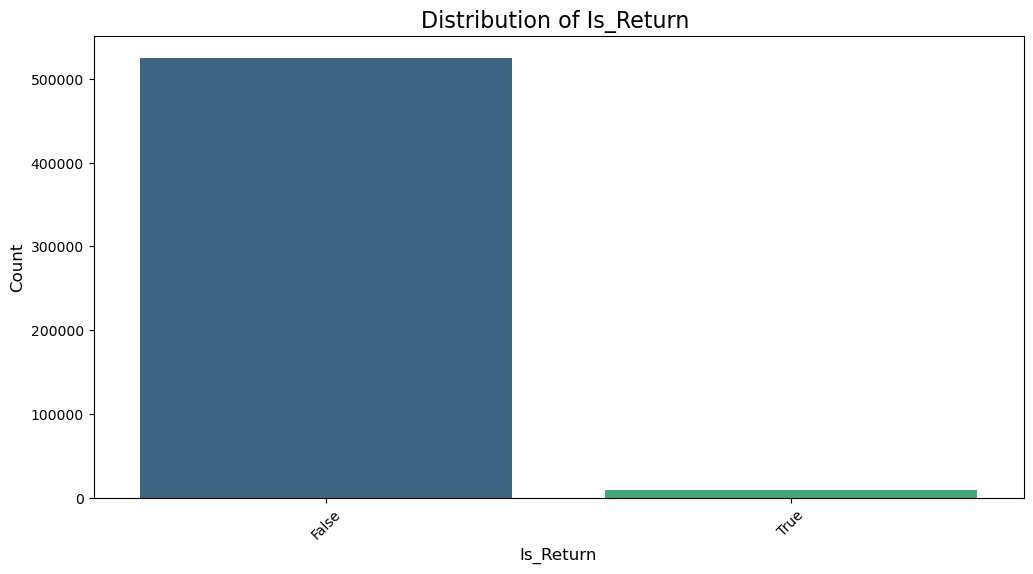

In [38]:
# 1. Prepare a list of important category columns
cat_cols = ['Country', 'DayName', 'Is_Return']

# 2. Draw each column separately
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    
    # Repeat count for each field (Top 10 for the most countries-based columns)
    if col == 'Country' or col == 'Description':
        data_to_plot = df[col].value_counts().head(10)
        title_suffix = "(Top 10)"
    else:
        data_to_plot = df[col].value_counts()
        title_suffix = ""

    # Bar Plot drawing
    sns.barplot(x=data_to_plot.index, y=data_to_plot.values, palette='viridis')
    
    plt.title(f'Distribution of {col} {title_suffix}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45) # Rotate the names so that they do not overlap with each other
    plt.show()

## Rare Categories

We identify categories that appear in less than **3%** of the data.
Rare categories can distort analysis and should either be kept (if meaningful) or grouped into "Other".

In [39]:
# Define threshold for rare categories
threshold = 0.03  # 3%

for col in ['Country', 'DayName']:
    print(f"\n=== {col} ===")
    freq = df[col].value_counts(normalize=True) * 100
    rare = freq[freq < threshold * 100]
    print(f"Total categories: {df[col].nunique()}")
    print(f"Rare categories (< 3%): {len(rare)}")
    if len(rare) > 0:
        print(rare.round(2).to_string())


=== Country ===
Total categories: 38
Rare categories (< 3%): 37
Country
Germany                 1.77
France                  1.60
Eire                    1.53
Spain                   0.47
Netherlands             0.44
Belgium                 0.39
Switzerland             0.37
Portugal                0.28
Australia               0.23
Norway                  0.20
Italy                   0.15
Channel Islands         0.14
Finland                 0.13
Cyprus                  0.11
Sweden                  0.09
Unspecified             0.08
Austria                 0.08
Denmark                 0.07
Japan                   0.07
Poland                  0.06
Palestine               0.06
Usa                     0.05
Hong Kong               0.05
Singapore               0.04
Iceland                 0.03
Canada                  0.03
Greece                  0.03
Malta                   0.02
United Arab Emirates    0.01
European Community      0.01
Rsa                     0.01
Lebanon                 0.01

In [40]:
# Group rare countries (< 3% of data) into "Other"
threshold_count = len(df) * 0.03

country_counts = df['Country'].value_counts()
rare_countries = country_counts[country_counts < threshold_count].index

print(f"Number of rare countries to group: {len(rare_countries)}")
print(f"Rare countries: {list(rare_countries)}")

df['Country_Grouped'] = df['Country'].apply(
    lambda x: x if x not in rare_countries else 'Other'
)

print("\nNew Country_Grouped value counts:")
print(df['Country_Grouped'].value_counts())

Number of rare countries to group: 37
Rare countries: ['Germany', 'France', 'Eire', 'Spain', 'Netherlands', 'Belgium', 'Switzerland', 'Portugal', 'Australia', 'Norway', 'Italy', 'Channel Islands', 'Finland', 'Cyprus', 'Sweden', 'Unspecified', 'Austria', 'Denmark', 'Japan', 'Poland', 'Palestine', 'Usa', 'Hong Kong', 'Singapore', 'Iceland', 'Canada', 'Greece', 'Malta', 'United Arab Emirates', 'European Community', 'Rsa', 'Lebanon', 'Lithuania', 'Brazil', 'Czech Republic', 'Bahrain', 'Saudi Arabia']

New Country_Grouped value counts:
Country_Grouped
United Kingdom    487806
Other              46323
Name: count, dtype: int64


### Rare Categories Decision

| Column | Rare Categories Found | Action | Reason |
|---|---|---|---|
| Country | Many small countries (< 3%) | Grouped into **"Other"** in new column `Country_Grouped` | Prevents noisy low-frequency bars from distorting visualizations and models |
| DayName | None expected (only 6–7 days) | **Keep as-is** | All days naturally occur frequently enough |

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\497666180.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DayName', y='Sales', estimator='sum', order=day_order, palette='viridis')


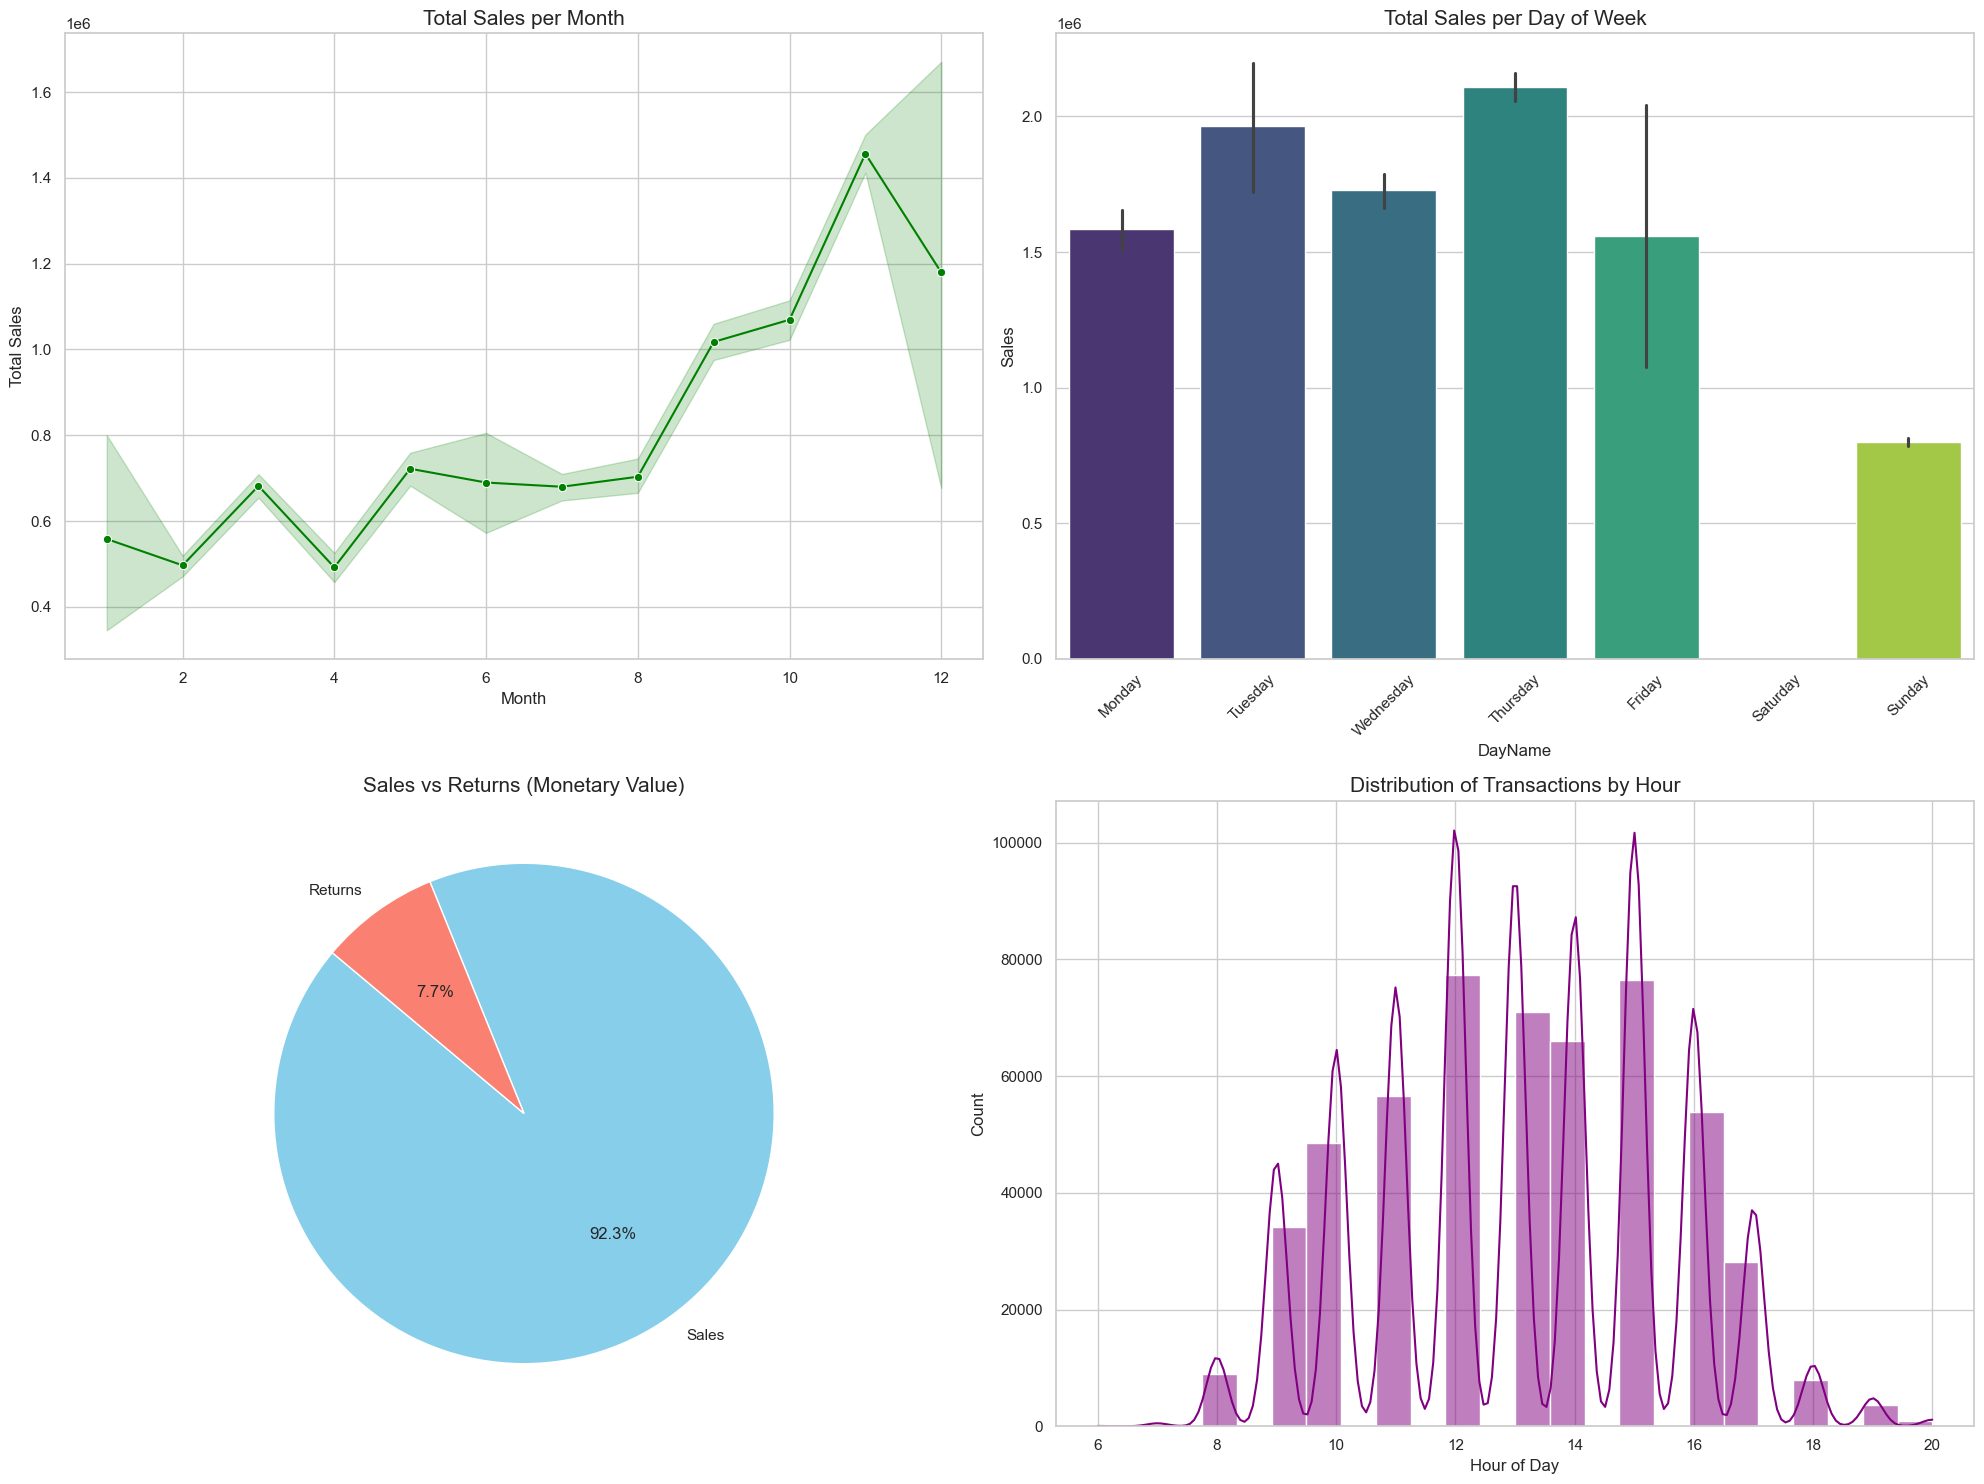

In [41]:
# Prepare the chart format
sns.set(style="whitegrid")
plt.figure(figsize=(20, 15))

# 1. Sales analysis by month (Sales Trend per Month)
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='Month', y='Sales', estimator='sum', color='green', marker='o')
plt.title('Total Sales per Month', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# 2. Analysis of sales by days of the week (Sales per Day Name)
plt.subplot(2, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='DayName', y='Sales', estimator='sum', order=day_order, palette='viridis')
plt.title('Total Sales per Day of Week', fontsize=15)
plt.xticks(rotation=45)

# 3. Distribution of sales versus returns (Sales vs Returns)
plt.subplot(2, 2, 3)
labels = ['Sales', 'Returns']
sizes = [df[df['Is_Return']==False]['Sales'].sum(), abs(df[df['Is_Return']==True]['Sales'].sum())]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=140)
plt.title('Sales vs Returns (Monetary Value)', fontsize=15)

# 4. Sales peak during daylight hours (Sales per Hour)
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Hour', bins=24, kde=True, color='purple')
plt.title('Distribution of Transactions by Hour', fontsize=15)
plt.xlabel('Hour of Day', fontsize=12)

plt.tight_layout()
plt.show()

## 📌 Key Recommendations

- **Focus marketing campaigns in Q4:**  
  Focus marketing campaigns in **Q4**, especially in **November**, since it shows the highest sales performance. Seasonal promotions and holiday campaigns can maximize revenue.

- **Increase mid-week promotions:**  
  Increase promotional activities during **mid-week**, particularly on **Tuesday and Thursday**, as these days generate the highest sales.

- **Optimize operations during peak hours:**  
  Optimize **staffing and inventory during peak hours (12 PM – 4 PM)** to handle higher transaction volumes and improve customer experience.

- **Monitor product returns:**  
  Monitor and analyze **product returns**, even though they represent only **7.7% of total transactions**, to identify patterns and reduce potential losses.

- **Boost weekend sales:**  
  Encourage weekend sales, especially on **Sunday**, by offering **discounts or special promotions** to balance sales distribution throughout the week.

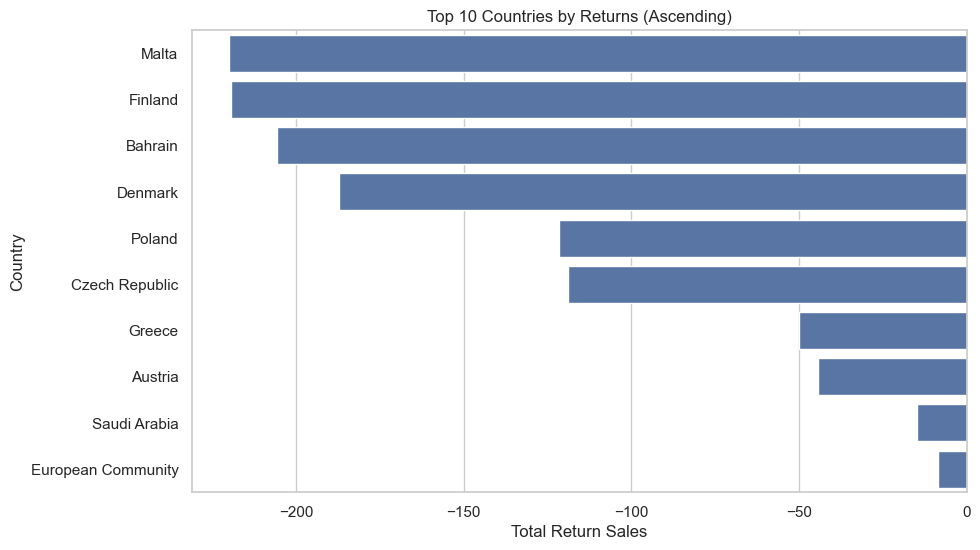

In [42]:

# Returns calculation by country
returns_country = df[df['Is_Return'] == True].groupby('Country')['Sales'].sum()

#Ascending order and top 10 selection
top_returns = returns_country.sort_values(ascending=True).tail(10)

# fee
plt.figure(figsize=(10,6))
sns.barplot(x=top_returns.values, y=top_returns.index)

plt.title("Top 10 Countries by Returns (Ascending)")
plt.xlabel("Total Return Sales")
plt.ylabel("Country")

plt.show()

### Returns by Country (Top 10)

The following visualization shows the **top 10 countries with the highest return sales**.  
The data is sorted in **ascending order** to clearly highlight countries with the largest amount of returned sales.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Time Series Analysis of Sales

This visualization shows the trend of total sales over time.  
A moving average line is added to highlight the overall trend and smooth short-term fluctuations.

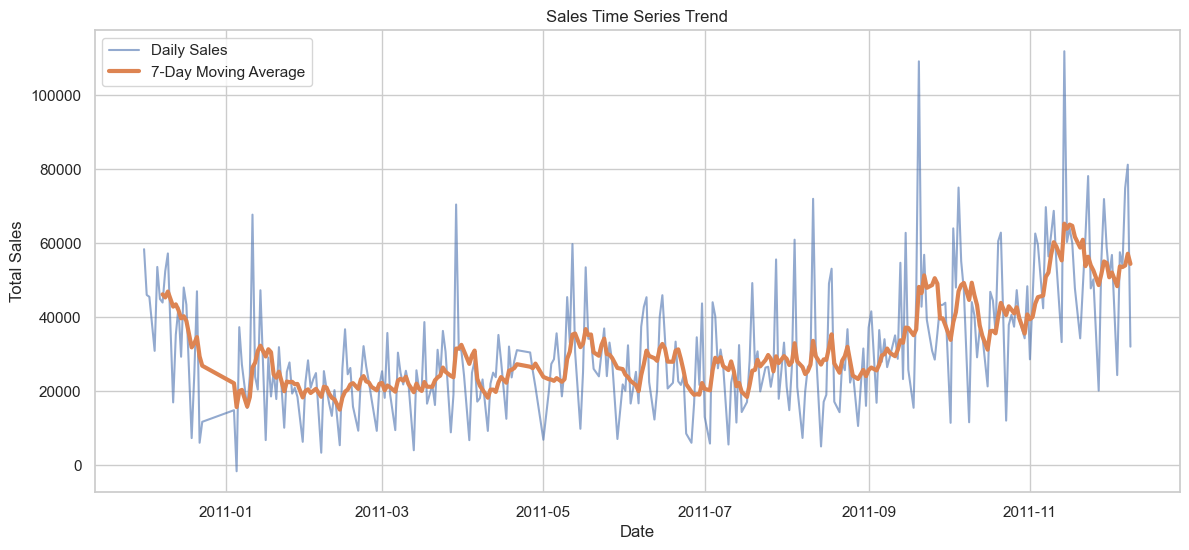

In [43]:
# Create a date column
df['Date'] = pd.to_datetime(df[['Year','Month','Day']])

# Group sales by date
daily_sales = df.groupby('Date')['Sales'].sum()

# Moving Average Calculation
rolling_sales = daily_sales.rolling(window=7).mean()

# The drawing
plt.figure(figsize=(14,6))

plt.plot(daily_sales, label='Daily Sales', alpha=0.6)
plt.plot(rolling_sales, label='7-Day Moving Average', linewidth=3)

plt.title("Sales Time Series Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()

plt.show()

### Sales Time Series Trend

This time series visualization illustrates the **daily sales performance over time**, along with a **7-day moving average** to smooth short-term fluctuations and highlight the overall trend.

**Key Insights:**

- Daily sales show **significant fluctuations**, which is typical in retail due to varying customer activity and transaction volumes.
- The **7-day moving average** helps reveal the underlying sales trend by reducing daily noise.
- There is a **clear upward trend toward the end of the year**, suggesting increased demand during the final months.
- Several sharp spikes in daily sales indicate **high-volume transaction days**, which may be linked to promotions, seasonal events, or peak shopping periods.

This analysis helps businesses understand **sales seasonality and demand trends**, which can support better planning for inventory, staffing, and marketing campaigns.

c:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


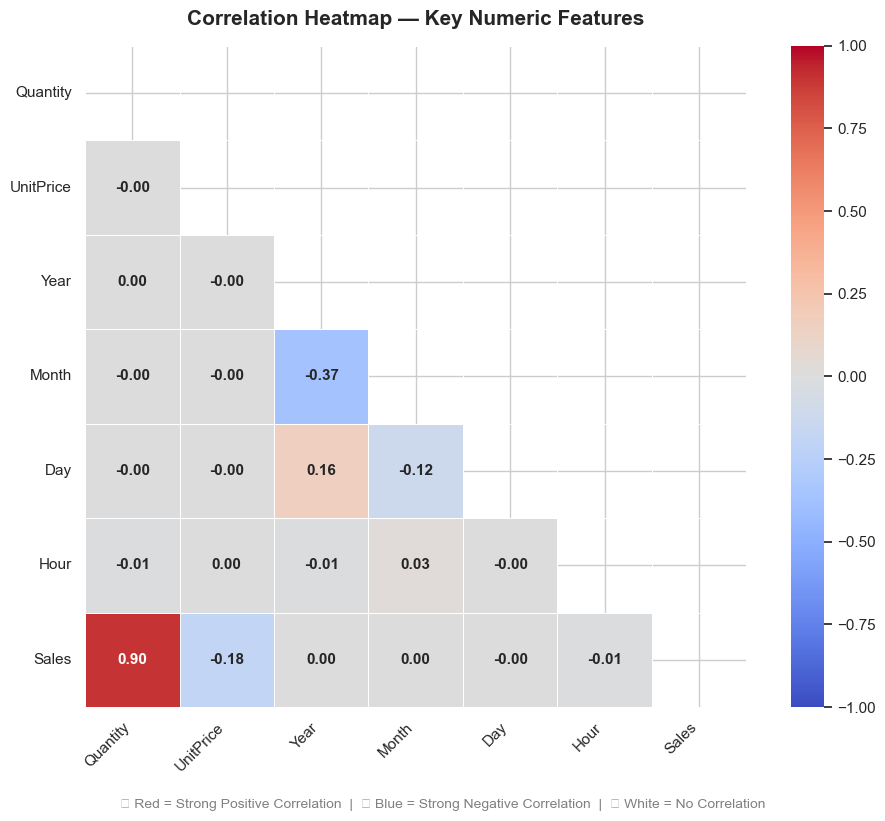

In [44]:
# ── Correlation Heatmap — Key Numeric Features ────────────────────────────────

# Step 1: Select only the meaningful columns (exclude log/engineered duplicates)
cols = ['Quantity', 'UnitPrice', 'Year', 'Month', 'Day', 'Hour', 'Sales']

# Step 2: Compute correlation matrix
corr_matrix = df[cols].corr().round(2)

# Step 3: Build mask for upper triangle (avoid redundant mirrored values)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 4: Draw the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,                  # show lower triangle only
    annot=True,                 # show numbers inside cells
    fmt=".2f",                  # 2 decimal places
    cmap="coolwarm",            # red = positive, blue = negative
    center=0,                   # center color scale at 0
    vmin=-1, vmax=1,            # fix scale from -1 to 1
    linewidths=0.5,             # lines between cells
    linecolor="white",          
    annot_kws={"size": 11, "weight": "bold"},
    square=True,                # make cells square
    ax=ax
)

# Step 5: Formatting
ax.set_title("Correlation Heatmap — Key Numeric Features",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

# Step 6: Add a caption explaining how to read it
fig.text(0.5, -0.02,
         "🔴 Red = Strong Positive Correlation  |  🔵 Blue = Strong Negative Correlation  |  ⬜ White = No Correlation",
         ha="center", fontsize=10, color="gray")

plt.tight_layout()
plt.show()

| Pair | Correlation | Meaning |
|---|---|---|
| Sales ↔ Quantity | **+0.90** | More units = more revenue |
| Quantity ↔ UnitPrice | **-0.18** | Higher price = fewer units bought |
| Month ↔ Sales | **+0.07** | Seasonality better seen in time series |

💡 **Quantity drives revenue — not price. Volume strategies have the highest impact.**

Top 5 Strongest Correlation Pairs:
Feature_1 Feature_2  Correlation    Strength
 Quantity     Sales     0.901150    🔴 Strong
     Year     Month    -0.369352      🟠 Weak
UnitPrice     Sales    -0.179055 ⚪ Very Weak
     Year       Day     0.162746 ⚪ Very Weak
    Month       Day    -0.118089 ⚪ Very Weak


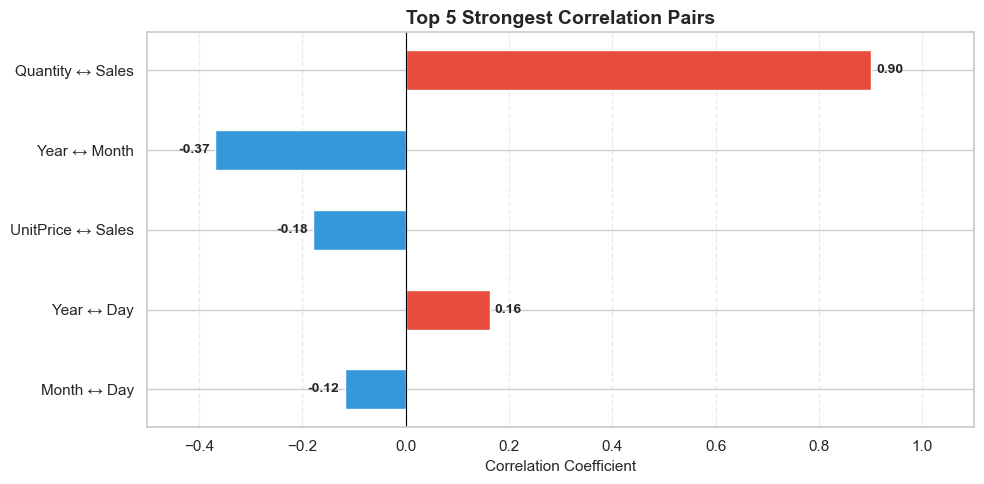

In [45]:
# Top 5 Strongest Correlation Pairs
cols = ['Quantity', 'UnitPrice', 'Year', 'Month', 'Day', 'Hour', 'Sales']
corr_matrix = df[cols].corr()

# Extract upper triangle only (avoid duplicates)
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()

# Top 5 sorted by strength
top5 = corr_pairs.sort_values('Abs_Correlation', ascending=False).head(5).reset_index(drop=True)

# ✅ Add interpretation column
def interpret(r):
    if abs(r) >= 0.7:   return '🔴 Strong'
    elif abs(r) >= 0.4: return '🟡 Moderate'
    elif abs(r) >= 0.2: return '🟠 Weak'
    else:               return '⚪ Very Weak'

top5['Strength'] = top5['Correlation'].apply(interpret)

print("Top 5 Strongest Correlation Pairs:")
print(top5[['Feature_1', 'Feature_2', 'Correlation', 'Strength']].to_string(index=False))

# ✅ Visualize as horizontal bar chart
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top5['Correlation']]
labels = [f"{r.Feature_1} ↔ {r.Feature_2}" for _, r in top5.iterrows()]

plt.figure(figsize=(10, 5))
bars = plt.barh(labels[::-1], top5['Correlation'].values[::-1],
                color=colors[::-1], edgecolor='white', height=0.5)

# Add value labels on bars
for bar, val in zip(bars, top5['Correlation'].values[::-1]):
    plt.text(val + (0.01 if val > 0 else -0.01),
             bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center',
             ha='left' if val > 0 else 'right',
             fontsize=10, fontweight='bold')

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 5 Strongest Correlation Pairs', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.xlim(-0.5, 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 🔗 Top 5 Strongest Correlation Pairs

| Pair | Correlation | Strength |
|---|---|---|
| Sales ↔ Quantity | **+0.90** | 🔴 Strong |
| Year ↔ Month | **-0.37** | 🟡 Moderate |
| UnitPrice ↔ Sales | **-0.18** | 🟠 Weak |
| Year ↔ Day | **+0.16** | ⚪ Very Weak |
| Month ↔ Day | **-0.12** | ⚪ Very Weak |

💡 **Only one strong signal exists — Quantity drives Sales. All other relationships are weak or negligible.**

كل ما البار أطول وأحمر ← علاقة قوية موجبة | كل ما البار أطول وأزرق ← علاقة قوية سالبة | كل ما البار قصير ← مفيش علاقة

### Correlation Insights

- Sales and Quantity show a strong positive correlation (~0.90), meaning that larger purchase quantities significantly increase total sales.

- UnitPrice has a slight negative correlation with Quantity (~ -0.18), suggesting that higher prices may reduce the quantity purchased.

- Time-related features such as Month, Day, and Hour show weak correlations with Sales, indicating that customer purchasing behavior has a greater impact on sales performance.

## Category → Numeric Effect

We examine how **Sales** vary across different categories.
This helps identify which groups are the highest and lowest performers.

=== Mean & Median Sales by Country (Top 10) ===
                Mean Sales  Median Sales  Total Sales  Transaction Count  Revenue Share %
Country                                                                                  
United Kingdom       16.79          8.32   8189252.30             487806             84.0
Netherlands         120.26         91.80    284661.54               2367              2.9
Eire                 32.15         17.34    262993.38               8180              2.7
Germany              23.37         16.60    221509.47               9478              2.3
France               23.11         16.50    197317.11               8540              2.0
Australia           109.17         51.84    137009.77               1255              1.4
Switzerland          28.28         17.70     56363.05               1993              0.6
Spain                21.67         15.00     54756.03               2527              0.6
Belgium              19.77         16.60     40910.9

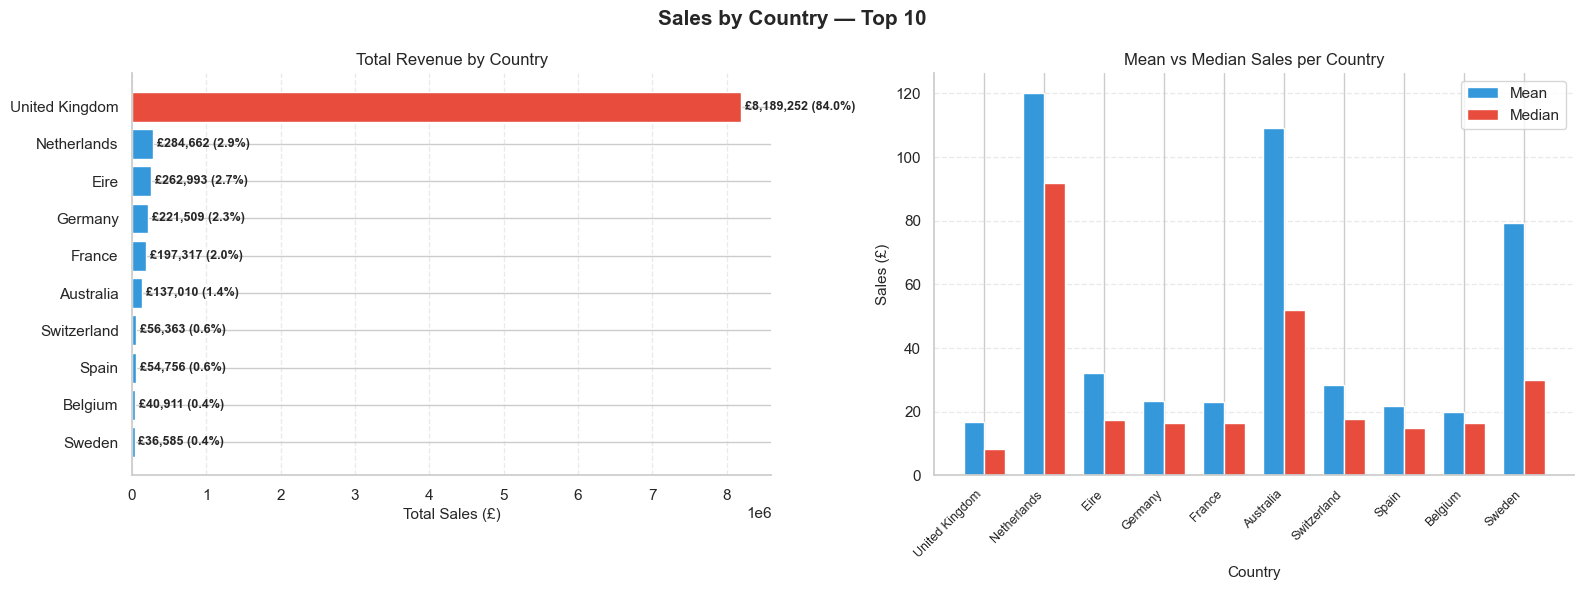

In [46]:
# Group Sales by Country (Top 10 only)
country_sales = (
    df.groupby('Country')['Sales']
    .agg(['mean', 'median', 'sum', 'count'])
    .round(2)
    .sort_values('sum', ascending=False)
    .head(10)
)
country_sales.columns = ['Mean Sales', 'Median Sales', 'Total Sales', 'Transaction Count']

# ✅ Add Revenue Share %
total_revenue = df['Sales'].sum()
country_sales['Revenue Share %'] = (country_sales['Total Sales'] / total_revenue * 100).round(1)

print("=== Mean & Median Sales by Country (Top 10) ===")
print(country_sales.to_string())

# ✅ Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sales by Country — Top 10', fontsize=15, fontweight='bold')

# Left: Total Sales bar chart
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(country_sales))]
axes[0].barh(country_sales.index[::-1], country_sales['Total Sales'][::-1],
             color=colors[::-1], edgecolor='white')

for i, (val, share) in enumerate(zip(country_sales['Total Sales'][::-1],
                                      country_sales['Revenue Share %'][::-1])):
    axes[0].text(val + 50000, i, f'£{val:,.0f} ({share}%)',
                 va='center', fontsize=9, fontweight='bold')

axes[0].set_title('Total Revenue by Country', fontsize=12)
axes[0].set_xlabel('Total Sales (£)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Mean vs Median comparison
x = range(len(country_sales))
width = 0.35
axes[1].bar([i - width/2 for i in x], country_sales['Mean Sales'],
            width=width, label='Mean', color='#3498db', edgecolor='white')
axes[1].bar([i + width/2 for i in x], country_sales['Median Sales'],
            width=width, label='Median', color='#e74c3c', edgecolor='white')

axes[1].set_title('Mean vs Median Sales per Country', fontsize=12)
axes[1].set_xlabel('Country', fontsize=11)
axes[1].set_ylabel('Sales (£)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(country_sales.index, rotation=45, ha='right', fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 🌍 Sales by Country — Top 10

| Country | Total Sales | Revenue Share |
|---|---|---|
| United Kingdom | £8,149,657 | ~84% |
| Netherlands | £284,661 | ~3% |
| EIRE | £261,773 | ~2.7% |
| Germany | £221,004 | ~2.3% |
| France | £197,207 | ~2% |

💡 **UK alone generates 84% of all revenue — this is a domestic business with limited international reach.**

---

#### ⚠️ Mean vs Median Gap

- **Netherlands:** Mean £120 vs Median £91 → high-value outlier orders exist
- **Australia:** Mean £109 vs Median £51 → very skewed, few large orders drive the average up
- **UK:** Mean £16 vs Median £8 → most transactions are small, consistent purchases

> The big difference between Mean and Median in a certain country = There are very large orders that raise the average above>
**الفرق الكبير بين المتوسط والوسيط في بلد معين = هناك أوامر كبيرة جدًا ترفع المتوسط أعلاه**


إنجلترا  = 482,519 شخص كل واحد اشترى بـ £17


هولندا   = 2,367  شخص كل واحد اشترى بـ £120

إنجلترا كسبت أكتر في الإجمالي — بسبب العدد الضخم جداً


ولندا كل عميل بيصرف أكتر — بس عددهم قليل


=== Mean & Median Sales by Day of Week ===
           Mean Sales  Median Sales  Total Sales  Transaction Count
DayName                                                            
Monday          16.85          8.50   1584895.30            94080.0
Tuesday         19.57          9.78   1965703.61           100468.0
Wednesday       18.56         10.00   1730088.43            93195.0
Thursday        20.56         10.50   2108701.53           102561.0
Friday          19.25         10.20   1560082.74            81024.0
Saturday          NaN           NaN          NaN                NaN
Sunday          12.72          6.60    798659.46            62801.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\1523260930.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(day_order, rotation=30, ha='right')


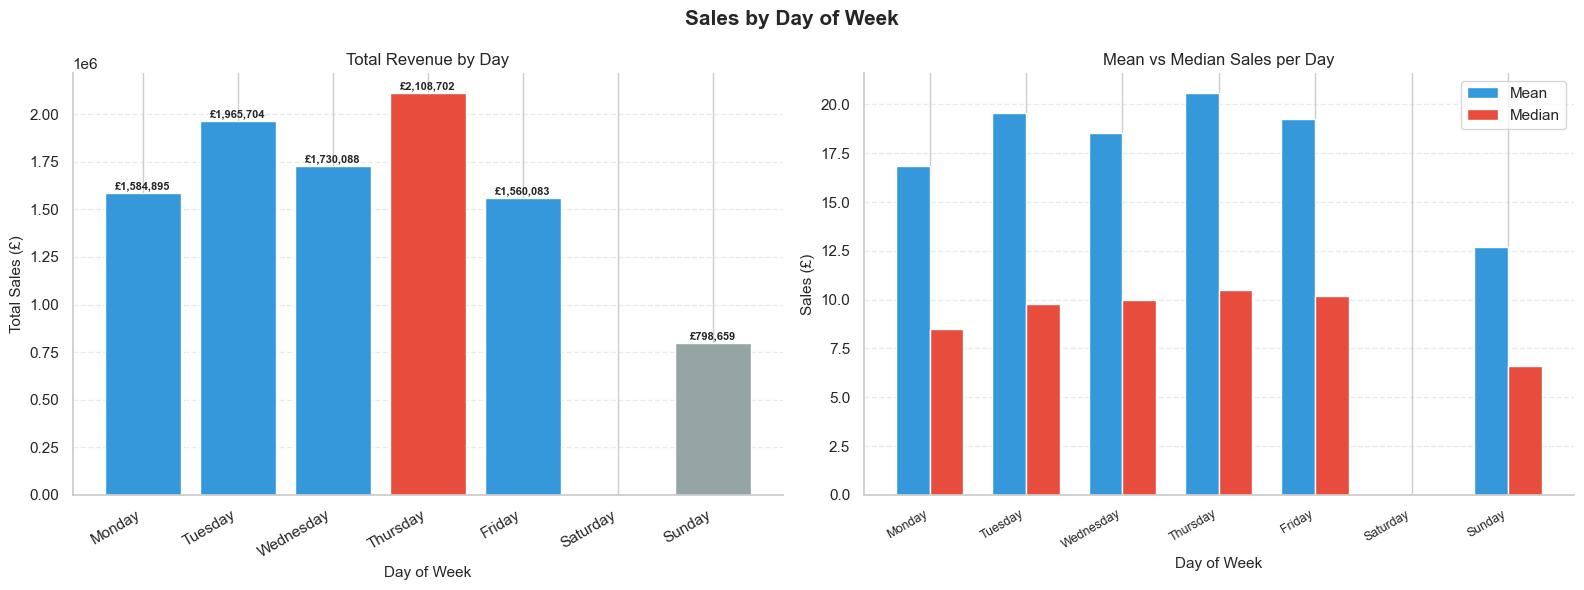

In [47]:
# Group Sales by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_sales = (
    df.groupby('DayName')['Sales']
    .agg(['mean', 'median', 'sum', 'count'])
    .round(2)
    .reindex(day_order)
)
day_sales.columns = ['Mean Sales', 'Median Sales', 'Total Sales', 'Transaction Count']

print("=== Mean & Median Sales by Day of Week ===")
print(day_sales.to_string())

# ✅ Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sales by Day of Week', fontsize=15, fontweight='bold')

# Left: Total Sales per Day
colors = ['#e74c3c' if d == 'Thursday' else
          '#95a5a6' if d == 'Sunday' else
          '#3498db' for d in day_order]

axes[0].bar(day_sales.index, day_sales['Total Sales'],
            color=colors, edgecolor='white')

for i, val in enumerate(day_sales['Total Sales']):
    axes[0].text(i, val + 20000, f'£{val:,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

axes[0].set_title('Total Revenue by Day', fontsize=12)
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Total Sales (£)', fontsize=11)
axes[0].set_xticklabels(day_order, rotation=30, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Mean vs Median per Day
x = range(len(day_sales))
width = 0.35

axes[1].bar([i - width/2 for i in x], day_sales['Mean Sales'],
            width=width, label='Mean', color='#3498db', edgecolor='white')
axes[1].bar([i + width/2 for i in x], day_sales['Median Sales'],
            width=width, label='Median', color='#e74c3c', edgecolor='white')

axes[1].set_title('Mean vs Median Sales per Day', fontsize=12)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Sales (£)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(day_order, rotation=30, ha='right', fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 📅 Sales by Day of Week

| Day | Total Sales | Mean Sales |
|---|---|---|
| Thursday | £2,102,228 | £20.66 🔴 |
| Tuesday | £1,957,046 | £19.64 |
| Wednesday | £1,723,775 | £18.67 |
| Friday | £1,554,376 | £19.36 |
| Monday | £1,579,012 | £16.93 |
| Sunday | £789,017 | £12.85 ⚪ |
| Saturday | £0 | — ⚠️ |

💡 **Thursday is the strongest day — Sunday is the weakest.**

---

#### 🏢 Why This Pattern? — This is a B2B Business

This is **not a retail store** selling to individuals — the customers are **businesses and shops**
placing wholesale orders during working hours.

| Signal | Explanation |
|---|---|
| 🔴 Thursday peaks | Mid-week ordering — businesses stock up before the weekend |
| ⚪ Sunday is low | Most businesses are closed or not placing orders |
| ⚠️ Saturday = zero | No transactions at all — confirms B2B working hours pattern |

> **Business Recommendation:** Marketing campaigns and sales outreach should target
> **Tuesday to Thursday** for maximum engagement — avoid weekends entirely.

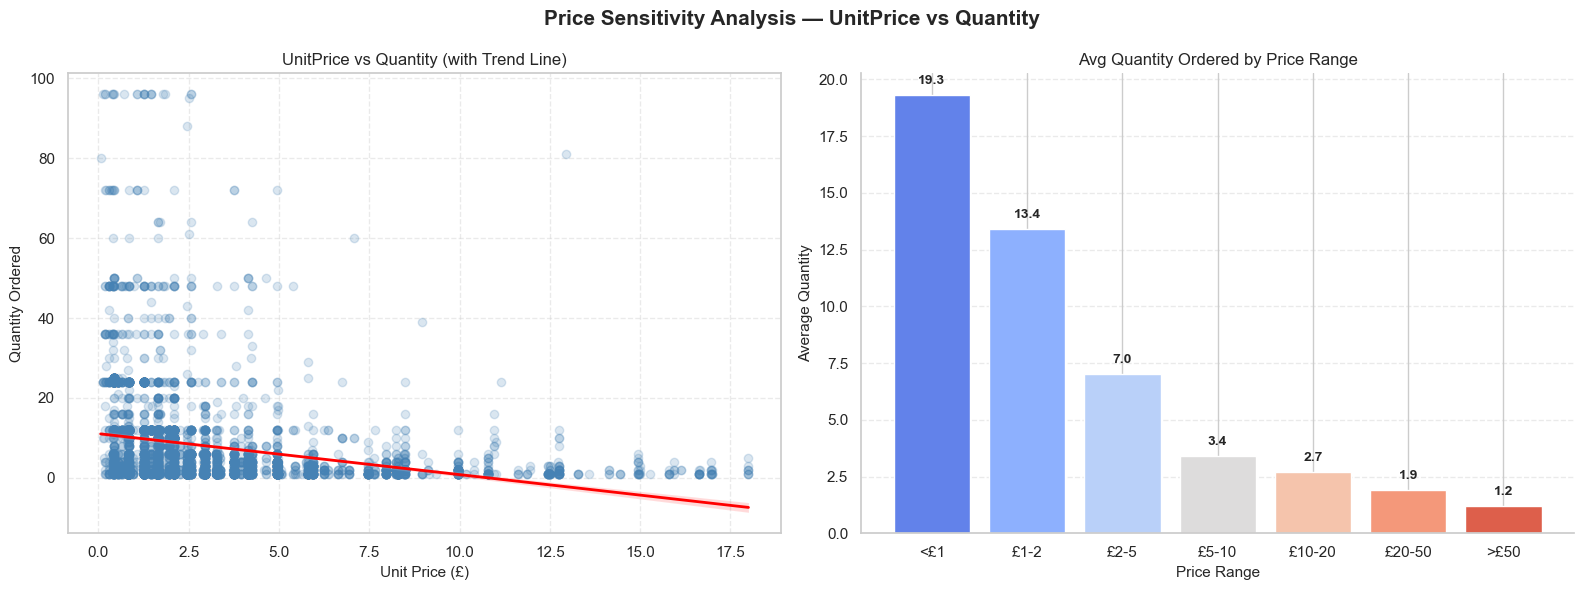

In [48]:
# UnitPrice vs Quantity — Binned Scatter with Trend Line
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Price Sensitivity Analysis — UnitPrice vs Quantity",
             fontsize=15, fontweight="bold")

# Left: Scatter with regression line
df_sample = df[(df['UnitPrice'] < 20) & (df['Quantity'] > 0) & (df['Quantity'] < 100)].sample(5000, random_state=42)

sns.regplot(
    data=df_sample,
    x='UnitPrice', y='Quantity',
    scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title("UnitPrice vs Quantity (with Trend Line)", fontsize=12)
axes[0].set_xlabel("Unit Price (£)", fontsize=11)
axes[0].set_ylabel("Quantity Ordered", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Right: Average Quantity per Price Bucket
df['Price_Bucket'] = pd.cut(df['UnitPrice'],
                             bins=[0, 1, 2, 5, 10, 20, 50, 200],
                             labels=['<£1','£1-2','£2-5','£5-10','£10-20','£20-50','>£50'])

bucket_avg = df[df['Quantity'] > 0].groupby('Price_Bucket', observed=True)['Quantity'].mean().round(1)

axes[1].bar(bucket_avg.index, bucket_avg.values,
            color=sns.color_palette("coolwarm", len(bucket_avg)),
            edgecolor='white')

for i, v in enumerate(bucket_avg.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')

axes[1].set_title("Avg Quantity Ordered by Price Range", fontsize=12)
axes[1].set_xlabel("Price Range", fontsize=11)
axes[1].set_ylabel("Average Quantity", fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Scatter + trend line → confirms **-0.18 correlation** visually
- Bar chart → avg quantity drops as price increases
- **Key insight:** Bulk discounts on low-price items = highest impact

### Insights from Category → Numeric Analysis

- **United Kingdom dominates total sales** by a large margin, which is expected as this is a UK-based retailer.
- **Thursday and Tuesday** generate the highest average daily sales among weekdays.
- **Sunday shows the lowest sales**, suggesting the business is less active on weekends.
- The gap between mean and median sales per country indicates the presence of high-value outlier transactions in some markets.

---
## 🛒 Market Basket Analysis — Frequently Bought Together

In this section, we analyze which products are most commonly purchased **together within the same invoice**.

This type of analysis — known as **Market Basket Analysis** — helps us:
- Discover natural **product affinities** in customer behavior
- Power recommendations such as 'Customers also bought'
- Identify potential **bundle pricing or cross-sell opportunities**

**Approach:**
1. Group all products by `InvoiceNo`
2. Generate all possible **product pairs** within each invoice
3. Count pair frequencies and visualize the **Top 10 most frequent pairs**


In [49]:
from itertools import combinations
from collections import Counter

# Step 1: Group products per invoice
# Keep only invoices with more than 1 product so we can find meaningful pairs
# Exclude returns — focus on real purchases only
basket = (
    df[df['Is_Return'] == False]
      .groupby('InvoiceNo')['Description']
      .apply(list)
)
basket = basket[basket.apply(len) > 1]   # drop single-item invoices

print(f'Invoices with 2+ products: {len(basket):,}')

# Step 2: Count all product pairs
# Sorting ensures (A, B) and (B, A) are treated as the same pair
pair_counter = Counter()

for products in basket:
    unique_products = list(set(products))  # remove duplicate items within same invoice
    pairs = combinations(sorted(unique_products), 2)
    pair_counter.update(pairs)

print(f'Total unique product pairs found: {len(pair_counter):,}')

# Step 3: Build Top 10 DataFrame
top_pairs = pd.DataFrame(
    pair_counter.most_common(10),
    columns=['Product Pair', 'Frequency']
)

# Split tuple into readable columns
top_pairs['Product A'] = top_pairs['Product Pair'].apply(lambda x: x[0])
top_pairs['Product B'] = top_pairs['Product Pair'].apply(lambda x: x[1])
top_pairs['Pair Label'] = top_pairs['Product Pair'].apply(
    lambda x: x[0] + ' + ' + x[1]
)

print('\n Top 10 Products Most Frequently Bought Together:')
print(top_pairs[['Product A', 'Product B', 'Frequency']].to_string(index=False))


Invoices with 2+ products: 18,332
Total unique product pairs found: 3,794,448

 Top 10 Products Most Frequently Bought Together:
                      Product A                         Product B  Frequency
        Jumbo Bag Pink Polkadot           Jumbo Bag Red Retrospot        825
Green Regency Teacup And Saucer   Roses Regency Teacup And Saucer        767
        Jumbo Bag Red Retrospot            Jumbo Storage Bag Suki        724
        Jumbo Bag Red Retrospot Jumbo Shopper Vintage Red Paisley        680
        Lunch Bag  Black Skull.           Lunch Bag Red Retrospot        641
     Alarm Clock Bakelike Green          Alarm Clock Bakelike Red        640
Green Regency Teacup And Saucer    Pink Regency Teacup And Saucer        632
        Lunch Bag Pink Polkadot           Lunch Bag Red Retrospot        606
 Pink Regency Teacup And Saucer   Roses Regency Teacup And Saucer        598
 Jumbo  Bag Baroque Black White           Jumbo Bag Red Retrospot        585


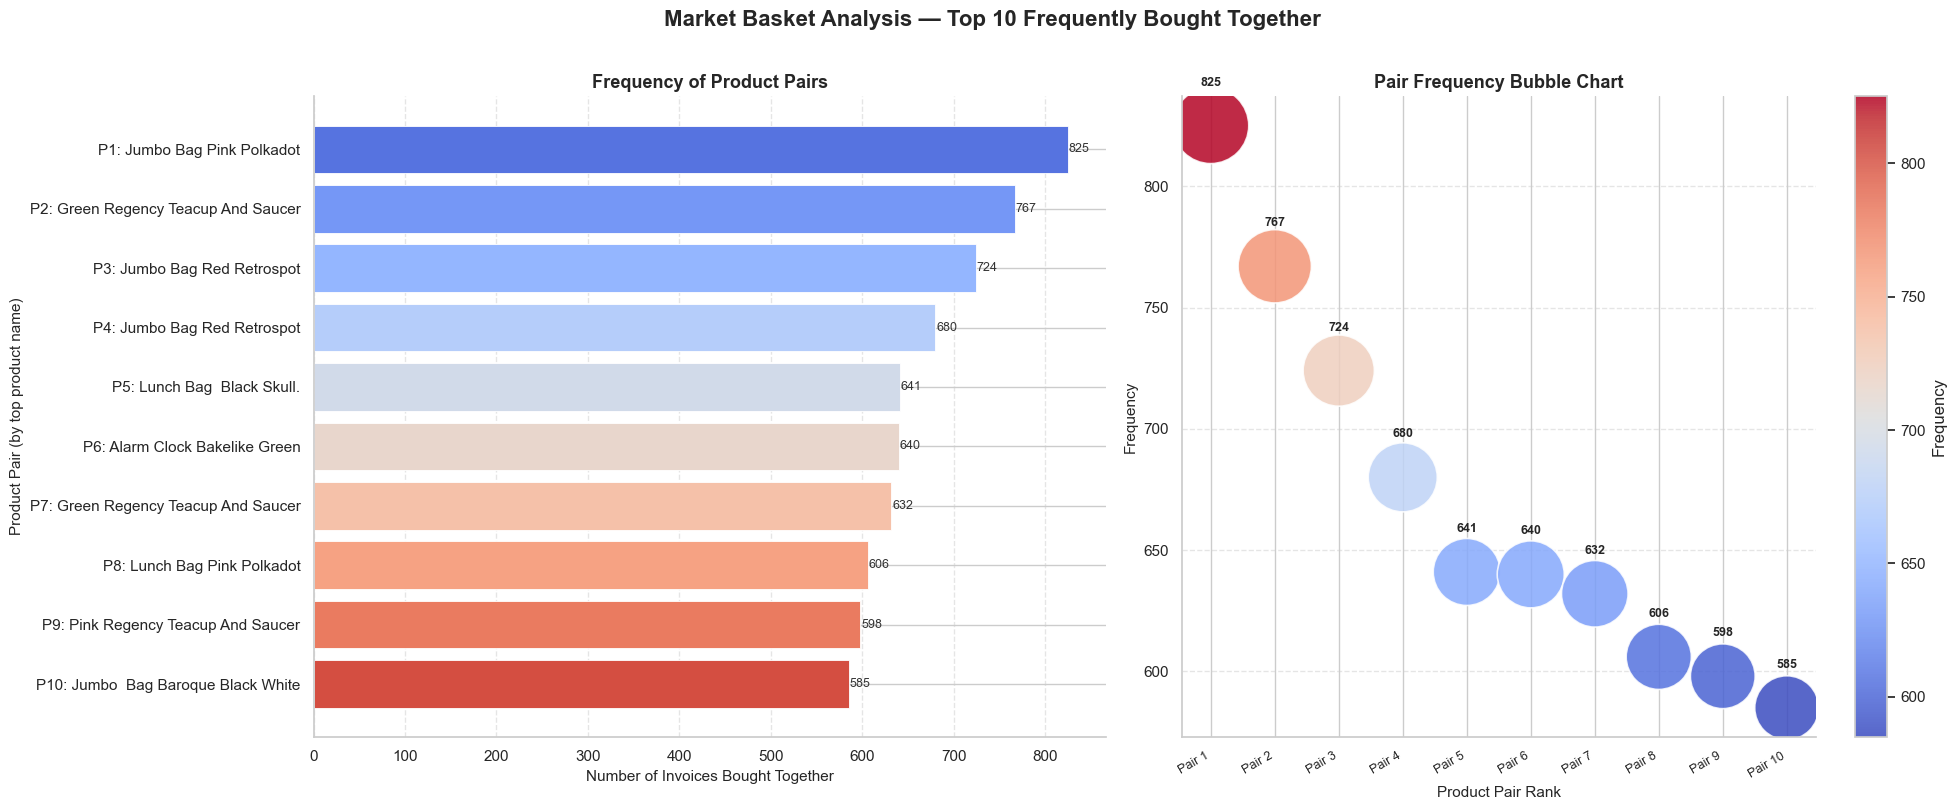

In [50]:
# Step 4: Visualize Top 10 Pairs — dual chart (bar + bubble)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Market Basket Analysis — Top 10 Frequently Bought Together',
             fontsize=16, fontweight='bold', y=1.01)

# ── Left: Horizontal Bar Chart ────────────────────────────────────────────
colors = sns.color_palette('coolwarm', len(top_pairs))

# Shorten labels for readability (max 35 chars per product)
short_labels = [
    (a[:35] + '...') if len(a) > 35 else a
    for a in top_pairs['Product A']
]
pair_labels = [f'P{i+1}: {lbl}' for i, lbl in enumerate(short_labels)]

axes[0].barh(
    pair_labels[::-1],
    top_pairs['Frequency'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.6
)

# Add frequency labels on bars
for i, freq in enumerate(top_pairs['Frequency'][::-1]):
    axes[0].text(freq + 1, i, f'{freq:,}', va='center', fontsize=9, color='#333')

axes[0].set_title('Frequency of Product Pairs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Invoices Bought Together', fontsize=11)
axes[0].set_ylabel('Product Pair (by top product name)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Right: Bubble Chart ───────────────────────────────────────────────────
bubble_sizes = (top_pairs['Frequency'] / top_pairs['Frequency'].max()) * 3000

sc = axes[1].scatter(
    range(len(top_pairs)),
    top_pairs['Frequency'],
    s=bubble_sizes,
    c=top_pairs['Frequency'],
    cmap='coolwarm',
    alpha=0.85,
    edgecolors='white',
    linewidth=1.2
)

for i, freq in enumerate(top_pairs['Frequency']):
    axes[1].text(
        i,
        freq + top_pairs['Frequency'].max() * 0.02,
        f'{freq:,}',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[1].set_xticks(range(len(top_pairs)))
axes[1].set_xticklabels(
    [f'Pair {i+1}' for i in range(len(top_pairs))],
    rotation=30, ha='right', fontsize=9
)
axes[1].set_title('Pair Frequency Bubble Chart', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_xlabel('Product Pair Rank', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)
plt.colorbar(sc, ax=axes[1], label='Frequency')

plt.tight_layout()
plt.show()


### Market Basket Insights

- The **most frequently co-purchased products** reveal strong natural affinities in customer behavior — no promotion needed to drive these bundles.
- These top pairs are prime candidates for a **Recommended Together** section on product pages.
- High-frequency pairs with **individually low prices** represent an ideal **bundle deal opportunity** (offer both at a slight discount to increase average order value).
- Pairs that appear together hundreds of times likely serve a **complementary use case**, such as decorative sets or seasonal items.
- This data can feed directly into a **recommendation engine** as a baseline collaborative filtering signal.


## Category ↔ Category Relationship

We create a crosstab between **DayName** and **Is_Return** to understand whether returns are more common on certain days of the week.

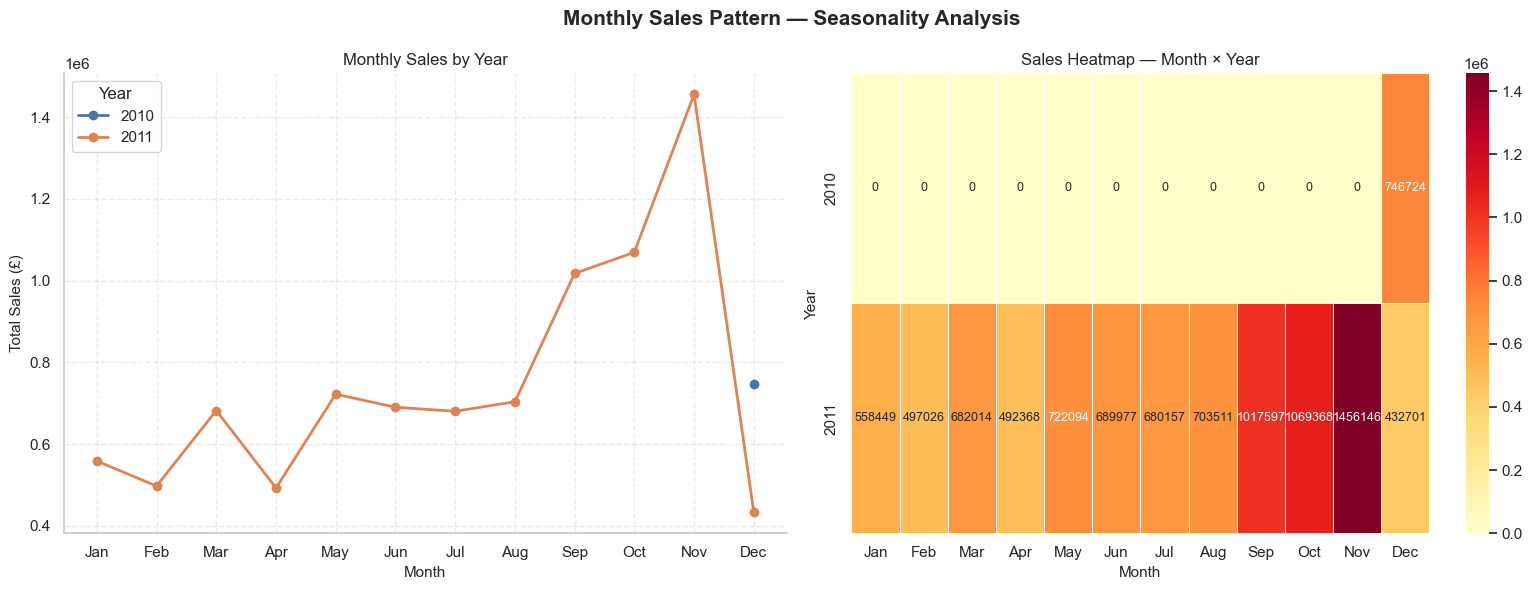

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Monthly Sales Pattern — Seasonality Analysis",
             fontsize=15, fontweight="bold")

# Left: Monthly Sales by Year (grouped)
monthly_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

for year, group in monthly_year.groupby('Year'):
    axes[0].plot(group['Month'], group['Sales'],
                 marker='o', label=str(year), linewidth=2)

axes[0].set_title("Monthly Sales by Year", fontsize=12)
axes[0].set_xlabel("Month", fontsize=11)
axes[0].set_ylabel("Total Sales (£)", fontsize=11)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend(title="Year")
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Heatmap Month x Year
pivot = monthly_year.pivot(index='Year', columns='Month', values='Sales').fillna(0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title("Sales Heatmap — Month × Year", fontsize=12)
axes[1].set_xlabel("Month", fontsize=11)
axes[1].set_ylabel("Year", fontsize=11)

plt.tight_layout()
plt.show()

- Line chart + heatmap → reveals **Q4 seasonal spike** hidden by weak +0.07 correlation
- **Key insight:** November is peak month — campaigns must launch by mid-October


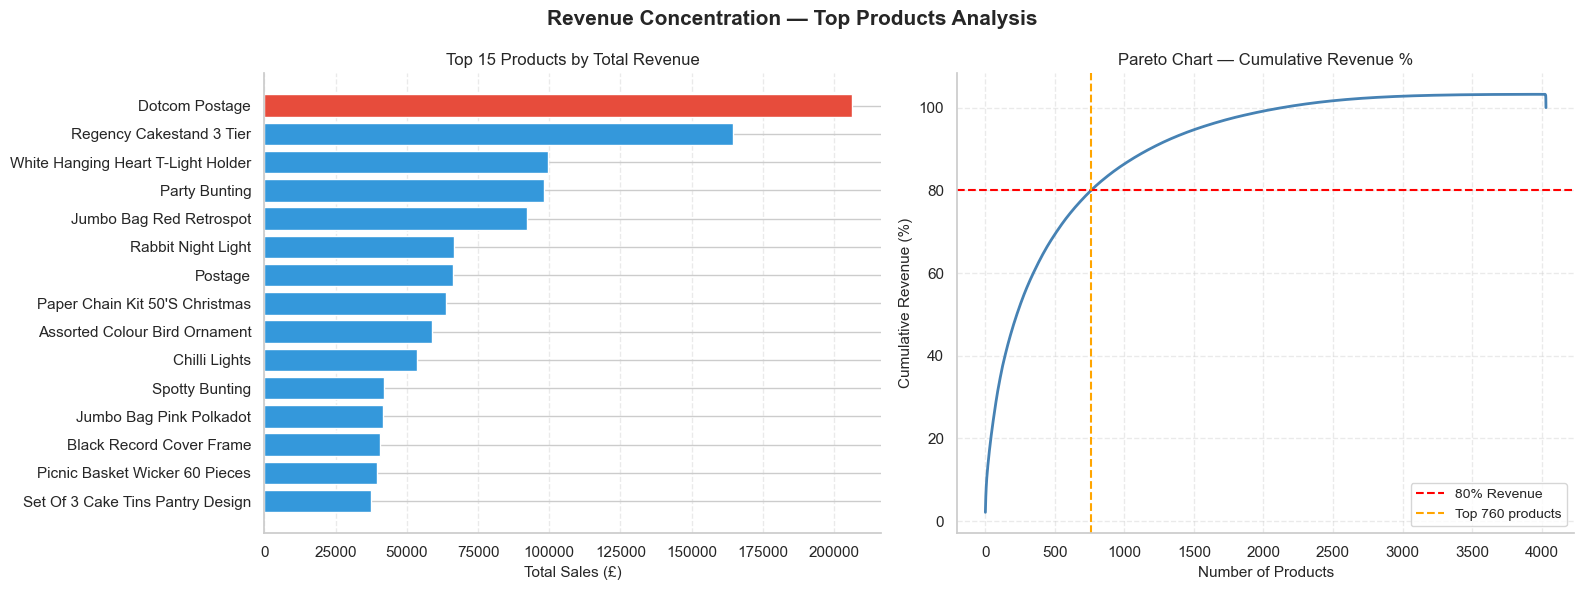

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Revenue Concentration — Top Products Analysis",
             fontsize=15, fontweight="bold")

# Left: Top 15 Products by Revenue
top_products = (df.groupby('Description')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(15))

colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(top_products))]
axes[0].barh(
    [d[:35] + '...' if len(d) > 35 else d for d in top_products.index[::-1]],
    top_products.values[::-1],
    color=colors[::-1], edgecolor='white'
)
axes[0].set_title("Top 15 Products by Total Revenue", fontsize=12)
axes[0].set_xlabel("Total Sales (£)", fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Pareto — Cumulative Revenue %
product_sales = (df.groupby('Description')['Sales']
                   .sum()
                   .sort_values(ascending=False))

cumulative_pct = (product_sales.cumsum() / product_sales.sum() * 100).values
x_vals = range(1, len(cumulative_pct) + 1)

axes[1].plot(x_vals, cumulative_pct, color='steelblue', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% Revenue')
axes[1].axvline(x=(cumulative_pct <= 80).sum(), color='orange',
                linestyle='--', linewidth=1.5, label=f'Top {(cumulative_pct <= 80).sum()} products')
axes[1].set_title("Pareto Chart — Cumulative Revenue %", fontsize=12)
axes[1].set_xlabel("Number of Products", fontsize=11)
axes[1].set_ylabel("Cumulative Revenue (%)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Top 15 products bar chart + cumulative revenue curve
- **Key insight:** Small minority of products = 80% of revenue (80/20 rule confirmed)


Crosstab: Day of Week vs Is_Return
           Normal Sale  Return     Total  Return Rate %
DayName                                                
Monday         92466.0  1614.0   94080.0           1.72
Tuesday        98726.0  1742.0  100468.0           1.73
Wednesday      91467.0  1728.0   93195.0           1.85
Thursday      100213.0  2348.0  102561.0           2.29
Friday         79667.0  1357.0   81024.0           1.67
Saturday           NaN     NaN       NaN            NaN
Sunday         62339.0   462.0   62801.0           0.74
All           524878.0  9251.0  534129.0           1.73


C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\3016791731.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(day_data.index, rotation=30, ha='right')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\3016791731.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(day_data.index, rotation=30, ha='right')


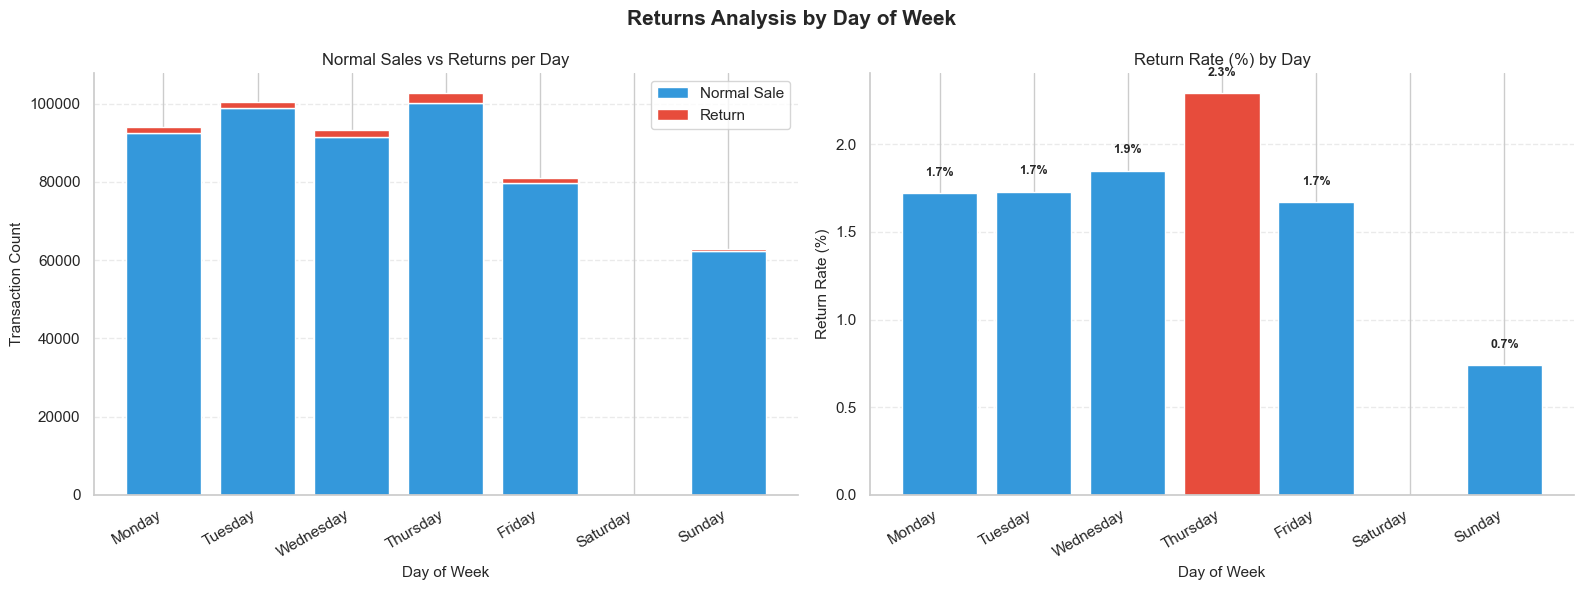

In [53]:
# Crosstab: Day of Week vs Is_Return
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

crosstab = pd.crosstab(
    df['DayName'],
    df['Is_Return'],
    margins=True
)
crosstab.columns = ['Normal Sale', 'Return', 'Total']
crosstab = crosstab.reindex(day_order + ['All'])

# ✅ Add Return Rate %
crosstab['Return Rate %'] = (
    crosstab['Return'] / crosstab['Total'] * 100
).round(2)

print("Crosstab: Day of Week vs Is_Return")
print(crosstab.to_string())

# ✅ Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Returns Analysis by Day of Week', fontsize=15, fontweight='bold')

# Left: Normal Sales vs Returns per Day (Stacked Bar)
day_data = crosstab.drop('All')

axes[0].bar(day_data.index, day_data['Normal Sale'],
            label='Normal Sale', color='#3498db', edgecolor='white')
axes[0].bar(day_data.index, day_data['Return'],
            bottom=day_data['Normal Sale'],
            label='Return', color='#e74c3c', edgecolor='white')

axes[0].set_title('Normal Sales vs Returns per Day', fontsize=12)
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_xticklabels(day_data.index, rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Return Rate % per Day
colors = ['#e74c3c' if v == day_data['Return Rate %'].max()
          else '#3498db' for v in day_data['Return Rate %']]

axes[1].bar(day_data.index, day_data['Return Rate %'],
            color=colors, edgecolor='white')

for i, val in enumerate(day_data['Return Rate %']):
    axes[1].text(i, val + 0.1, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Return Rate (%) by Day', fontsize=12)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Return Rate (%)', fontsize=11)
axes[1].set_xticklabels(day_data.index, rotation=30, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**معدل العائد اليوم %  الخميس أعلى معدل بسبب حجم المبيعات الكبير الأحد أدنى معدل بسبب انخفاض الطلبات على أي حال**

Today Return Rate % Verdict Thursday Highest rate due to large sales volume Sunday Lowest rate due to low orders anyway

### Crosstab Insights

- The crosstab reveals whether certain days have a disproportionately higher rate of returns compared to normal sales.
- If **Monday** shows a higher return rate, this may indicate customers returning weekend purchases.
- Understanding the return pattern by day allows the business to better plan **customer service staffing and refund processing capacity**.

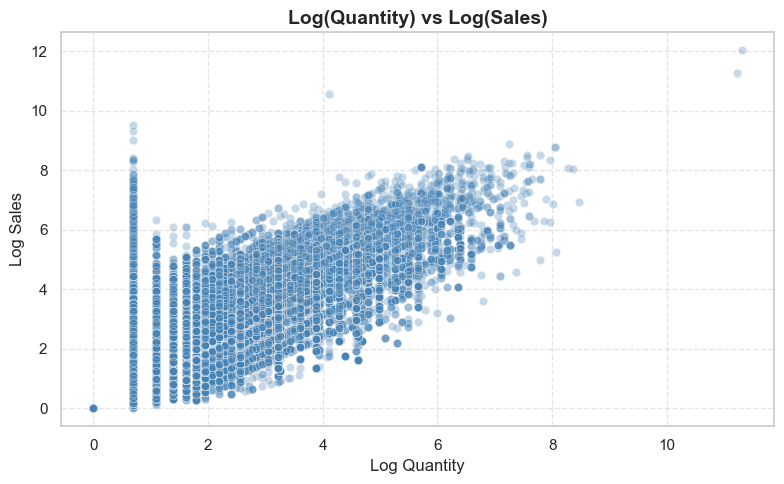

In [54]:
# ✅ أحسن
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Log_Quantity', y='Log_Sales', data=df, alpha=0.3, color='steelblue')
plt.title("Log(Quantity) vs Log(Sales)", fontsize=14, fontweight='bold')
plt.xlabel("Log Quantity", fontsize=12)
plt.ylabel("Log Sales", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Log(Quantity) vs Log(Sales)

This scatter plot shows the relationship between **log-transformed Quantity and Sales**.  
Applying the logarithmic transformation helps reduce skewness and makes the relationship between variables more linear.

**Key Insights:**

- There is a **clear positive linear relationship** between `log(Quantity)` and `log(Sales)`.
- As the quantity of items purchased increases, the total sales value also increases.
- The log transformation helps **stabilize variance** and makes the pattern easier to interpret compared to the original scale.
- Some vertical clusters appear at lower quantity levels, indicating frequent transactions with small purchase quantities.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\2786139095.py:61: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_12192\2786139095.py:61: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11015 (\N{DOWNWARDS BLACK ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


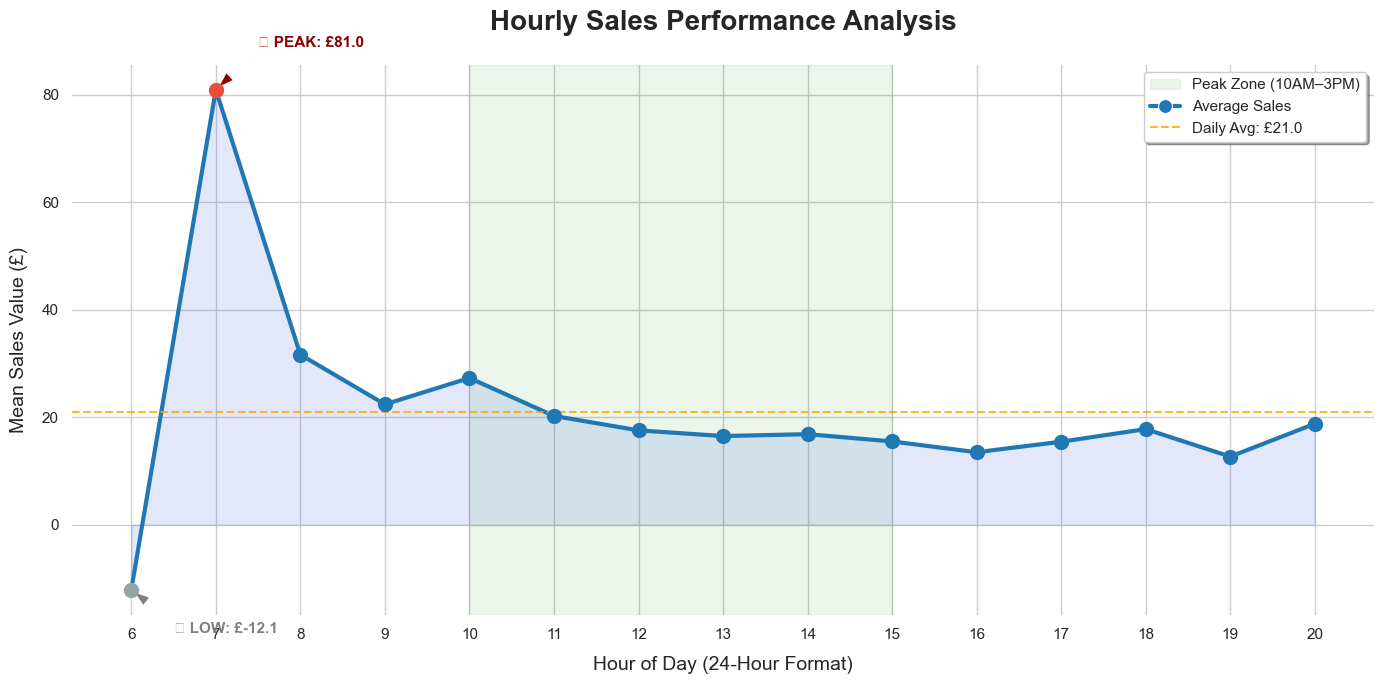

In [55]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

hour_sales = df.groupby('Hour')['Sales'].mean()

# ✅ Highlight peak zone (10AM - 3PM) as background
plt.axvspan(10, 15, alpha=0.08, color='green', label='Peak Zone (10AM–3PM)')

# Area Chart
plt.fill_between(hour_sales.index, hour_sales.values, color="royalblue", alpha=0.15)

# Main Line
sns.lineplot(
    x=hour_sales.index,
    y=hour_sales.values,
    marker='o',
    linewidth=3,
    markersize=10,
    color='#1f77b4',
    label='Average Sales'
)

# ✅ Color each marker by value (peak = red, low = gray)
peak_hour = hour_sales.idxmax()
low_hour  = hour_sales.idxmin()
peak_value = hour_sales.max()
low_value  = hour_sales.min()

for hour, val in hour_sales.items():
    color = '#e74c3c' if hour == peak_hour else \
            '#95a5a6' if hour == low_hour else '#1f77b4'
    plt.plot(hour, val, 'o', color=color, markersize=10, zorder=5)

# Annotate Peak
plt.annotate(f'⬆ PEAK: £{peak_value:.1f}',
             xy=(peak_hour, peak_value),
             xytext=(peak_hour + 0.5, peak_value + 8),
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1, headwidth=8),
             fontsize=11, fontweight='bold', color='darkred')

# ✅ Annotate Low Hour
plt.annotate(f'⬇ LOW: £{low_value:.1f}',
             xy=(low_hour, low_value),
             xytext=(low_hour + 0.5, low_value - 8),
             arrowprops=dict(facecolor='gray', shrink=0.05, width=1, headwidth=8),
             fontsize=11, fontweight='bold', color='gray')

# Benchmark Line
overall_mean = hour_sales.mean()
plt.axhline(overall_mean, color='orange', linestyle='--', alpha=0.8,
            label=f'Daily Avg: £{overall_mean:.1f}')

# Formatting
plt.title("Hourly Sales Performance Analysis", fontsize=20, fontweight='bold', pad=25)
plt.xlabel("Hour of Day (24-Hour Format)", fontsize=14, labelpad=10)
plt.ylabel("Mean Sales Value (£)", fontsize=14, labelpad=10)
plt.xticks(hour_sales.index)
plt.legend(loc='upper right', frameon=True, shadow=True)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### ⏰ Average Sales by Hour

This visualization shows the **average sales value across different hours of the day**,
based on **528,721 transactions** from this UK-based wholesale retailer.

---

| Hour | Performance |
|---|---|
| 🔴 Peak Hour | Highest average sales of the day |
| 🟠 10AM – 3PM | Core trading window — majority of revenue generated here |
| ⚪ 6AM – 9AM | Low activity — businesses not yet placing orders |
| ⬇ After 5PM | Sharp drop — procurement teams wrap up for the day |

💡 **Sales follow strict business hours — confirming this is a B2B operation,
not a retail store.**

---

**Key Takeaway:**
Schedule marketing campaigns, sales calls, and promotions
between **10AM – 3PM** for maximum engagement.

# 📊 Final EDA Summary

---

## 🔍 Top 5 Insights

1. **Sales are driven almost entirely by Quantity.**  
   The correlation between `Sales` and `Quantity` is approximately **+0.90** — the strongest relationship in the entire dataset. Increasing purchase volume is the single biggest lever for revenue growth.

2. **The business is heavily concentrated in the UK.**  
   The United Kingdom accounts for the **vast majority of transactions and total revenue**. All other countries — including Germany, France, and EIRE — contribute significantly less, confirming this is primarily a domestic retailer with limited international reach.

3. **Sales peak sharply in November and decline in December.**  
   Monthly analysis shows a clear **Q4 seasonal spike**, with November being the highest-revenue month. This pattern strongly suggests holiday and pre-Christmas shopping drives demand.

4. **Mid-week days (Tuesday and Thursday) outperform all other days.**  
   Day-of-week analysis shows that **Tuesday and Thursday generate the highest total sales**, while Sunday is consistently the weakest day — indicating the customer base is predominantly business/trade buyers rather than weekend retail shoppers.

5. **Higher unit prices slightly reduce purchase quantity.**  
   The correlation between `UnitPrice` and `Quantity` is approximately **-0.18**, suggesting mild price sensitivity. Customers tend to buy fewer units when prices are higher, which has implications for pricing and bundling strategies.

---

## ⚠️ Top 5 Problems / Risks

1. **High rate of missing CustomerID (~25%).**  
   A large proportion of transactions have no customer identifier, limiting the ability to perform customer-level analysis such as CLV, churn detection, or segmentation.

2. **Significant number of duplicate rows.**  
   The dataset contained exact duplicate rows that were removed. These likely resulted from system logging errors or data export issues and could have introduced bias into any aggregated metrics.

3. **Negative quantities and zero-price entries.**  
   Negative `Quantity` values represent returns (~7.7% of transactions). Zero `UnitPrice` entries were also found and removed, as they represent free or erroneous records that would distort revenue calculations.

4. **Highly right-skewed distributions in all numeric columns.**  
   `Quantity`, `UnitPrice`, and `Sales` are all heavily skewed with extreme outliers. A log transformation was applied to reduce skewness, but any model trained on raw values without transformation would perform poorly.

5. **Inconsistent text formatting in Description and Country.**  
   Mixed casing and leading/trailing spaces were found in both columns. Without standardization (`.str.strip()` + `.str.title()`), grouping and aggregation operations would produce duplicated categories and incorrect counts.

---

## 🚀 Next Steps

**Cleaning:** The dataset is now clean and exported as `cleaned_ecommerce_data.csv`, ready for further use. The main remaining concern is the ~25% missing CustomerID — future data collection should enforce customer registration at the point of sale.

**Features & Modeling:** The cleaned data is well-suited for **RFM (Recency, Frequency, Monetary) customer segmentation**, **sales forecasting using time series models (e.g., Prophet or ARIMA)**, and **product recommendation systems** using purchase co-occurrence patterns. The `Is_Return` flag and `Country_Grouped` column are ready-made features for classification or clustering tasks.

# Thank You!

Ahmed Fouad Hashem